Librerias

In [ ]:
# <-- Librerias para analisis de datos -->
import pandas as pd
import numpy as np

# <-- Librerias para visualización de datos -->
import seaborn as sns
import matplotlib.pyplot as plt

# <-- Librerias avanzadas -->
import joblib
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder

In [ ]:
def bins_calculator_fd(df:pd.DataFrame, column:str) -> int:
    '''
    args:
    - df (pandas.DataFrame): DataFrame sobre el que se calculara la cantidad de bins en una columna especifica.
    - column (str): Columna del DataFrame sobre la que se calculara la cantidad de bins.
    returns:
    - n_bins (int): Cantidad de bins para la columna, utilizando la formula de Freedman-Diaconis.
    '''

    # cálculo de IQR
    q1 = np.quantile(df[column], 0.25)
    q3 = np.quantile(df[column], 0.75)
    iqr = q3 - q1

    # cálculo de ancho de bins
    h_bins = (2 * iqr) / (df[column].shape[0] ** (1/3))

    # cálculo de n_bins
    n_bins = (max(df[column]) - min(df[column])) / h_bins

    return int(n_bins)

In [ ]:
#COMPLETAR
def limite_outliers(df: pd.DataFrame, column: str):
    '''
    Esta función recibe un dataframe junto con una columna, de la cual extraera el limite superior e inferior que separara los valores atípicos.

    args:
    - df (pandas.DataFrame): DataFrame de Pandas.
    - column (string): Nombre de la columna.

    returns:
    - (dict): Diccionario con limite inferior y superior
    '''

    if pd.api.types.is_numeric_dtype(df[column]):
        # definiendo los quartiles y el IQR según la formula de Tukey
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        IQR = Q3 - Q1

        # definiendo el limite inferior y superior para detectar los outliers

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        return dict([('limite_inferior' ,limite_inferior), ('limite_superior', limite_superior)])

Seteo de parametros por defecto para librerias

In [ ]:
# uso por defecto de tema de 'tableau'
plt.style.use('tableau-colorblind10')

# Parámetros base personalizados
matplotlib_base_params = {
    'figure.figsize': (10, 10),  # Tamaño de la figura
    'axes.labelsize': 12,        # Tamaño de la fuente de las etiquetas de los ejes
    'axes.titlesize': 14,        # Tamaño de la fuente del título de los ejes
    'xtick.labelsize': 10,       # Tamaño de la fuente de las marcas del eje X
    'ytick.labelsize': 10      # Tamaño de la fuente de las marcas del eje Y
    #'font.sans-serif': 'Verdana' # Fuente sans-serif
}


plt.rcParams.update(matplotlib_base_params)

In [ ]:
# diccionario para definir la paleta de colores por especie de flor

colores_especies = {
    'Iris-setosa': '#FF9999',   # Rojo suave
    'Iris-versicolor': '#66B3FF',  # Azul pastel
    'Iris-virginica': '#99FF99'   # Verde claro
}

In [ ]:
pandas_options_dict = {
    'display.max_rows': 100,
    'display.max_columns': 100,
    'display.max_colwidth': None,
    'display.float_format': '{:.2f}'.format,
    'display.width': 120,
    'mode.use_inf_as_na': True,
}

for option, valor in pandas_options_dict.items():
  pd.set_option(option, valor)

<ipython-input-119-72c95bd02e18>:11: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option(option, valor)


EDA Iris dataset: https://www.kaggle.com/datasets/uciml/iris

### Contexto y objetivo de la exploración

#### Información sobre el conjunto de datos:

Según una la fuente del dataset, este representa tres especies de iris con 50 muestras cada una, así como algunas propiedades de cada flor. Una especie de flor es linealmente separable de las otras dos, pero las otras dos no lo son entre sí.

Las columnas de este conjunto de datos son:







- Id -> Identificación
- SepalLengthCm -> Longitud del sépalo en cm
- SepalWidthCm -> Ancho del sépalo en cm
- PetalLengthCm -> Longitud del pétalo en cm
- PetalWidthCm -> Ancho del pétalo en cm
- Species -> Especies

Para comprender mejor las caracteristicas de este conjunto de datos, se importa una imagen de la estrucutra de una flor desde: *https://web.extension.illinois.edu/gpe_sp/images/otherparts.gif*


![Partes de una flor](https://web.extension.illinois.edu/gpe_sp/images/otherparts.gif)

#### Objetivo del analisis:

Se buscara información particular sobre cada una de las columnas con el objetivo de identificar preprocesamientos adecuados para cada una en cuanto a outliers, valores nulos, codificación y escalamiento; en segundo lugar tambien se identificara relaciónes entre caracateristics de las diferentes especies con el objetivo de en la etapa de ML poder evaluar posibles modelos que se ajusten mejor al conjunto de datos.

# EDA

## Exploración inicial del conjunto de datos:

In [ ]:
# lectura y carga del dataset
file_id = '1Yk9DQ_iI2rB3gl6GojMNkQfXEGtfhusf'
url = f'https://drive.google.com/uc?id={file_id}'

df = pd.read_csv(url)

In [ ]:
# Dimensionalidad del dataframe

df.shape

(150, 6)

In [ ]:
# Muestreo aleatorio

df.sample(n=5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
45,46,4.80,3.00,1.40,0.30,Iris-setosa
105,106,7.60,3.00,6.60,2.10,Iris-virginica
32,33,5.20,4.10,1.50,0.10,Iris-setosa
144,145,6.70,3.30,5.70,2.50,Iris-virginica
104,105,6.50,3.00,5.80,2.20,Iris-virginica


In [ ]:
# Primeros 5 registros

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.10,3.50,1.40,0.20,Iris-setosa
1,2,4.90,3.00,1.40,0.20,Iris-setosa
2,3,4.70,3.20,1.30,0.20,Iris-setosa
3,4,4.60,3.10,1.50,0.20,Iris-setosa
4,5,5.00,3.60,1.40,0.20,Iris-setosa


In [ ]:
# Ultimo 5 registros

df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.70,3.00,5.20,2.30,Iris-virginica
146,147,6.30,2.50,5.00,1.90,Iris-virginica
147,148,6.50,3.00,5.20,2.00,Iris-virginica
148,149,6.20,3.40,5.40,2.30,Iris-virginica
149,150,5.90,3.00,5.10,1.80,Iris-virginica


In [ ]:
df_limpio = df.copy()

In [ ]:
# Eliminación de columnas inecesarias

df_limpio.drop(columns=['Id'], inplace=True)

In [ ]:
# Rnombramiento de columnas a espańol

df_limpio.rename(columns={
                  'SepalLengthCm':'largo_sepalo_cm',
                  'SepalWidthCm':'ancho_sepalo_cm',
                  'PetalLengthCm':'largo_petalo_cm',
                  'PetalWidthCm':'ancho_petalo_cm',
                  'Species':'especies'
                  },
          inplace= True)

In [ ]:
# creación de columnas derivadas (area_sepalo)
df_limpio['area_sepalo'] = df_limpio['largo_sepalo_cm'] * df_limpio['ancho_sepalo_cm']

In [ ]:
# creación de columnas derivadas (area_petalo)
df_limpio['area_petalo'] = df_limpio['ancho_petalo_cm'] * df_limpio['largo_petalo_cm']

Metadatos de las columnas:

--

Tipo de dato de cada columna:

In [ ]:
# Tipos de datos

df_limpio.dtypes

,0
largo_sepalo_cm,float64
ancho_sepalo_cm,float64
largo_petalo_cm,float64
ancho_petalo_cm,float64
especies,object
area_sepalo,float64
area_petalo,float64


## Exploración univariable

### Valores nulos:

In [ ]:
df_limpio.isnull().sum()

,0
largo_sepalo_cm,0
ancho_sepalo_cm,0
largo_petalo_cm,0
ancho_petalo_cm,0
especies,0
area_sepalo,0
area_petalo,0


## Exploración de columnas categoricas:

In [ ]:
# seleccion y muestreo de columnas categoricas

df_limpio.select_dtypes(include='object')

,especies
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
...,...
145,Iris-virginica
146,Iris-virginica
147,Iris-virginica
148,Iris-virginica


### Frecuencia de valores unicos:

In [ ]:
# conteo de valores unicos por categoria

frecuencia_especies = df_limpio['especies'].value_counts()
frecuencia_especies

,count
especies,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


<ipython-input-134-8ec5d86f520c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=frecuencia_especies, palette=colores_especies, ax=ax[0])


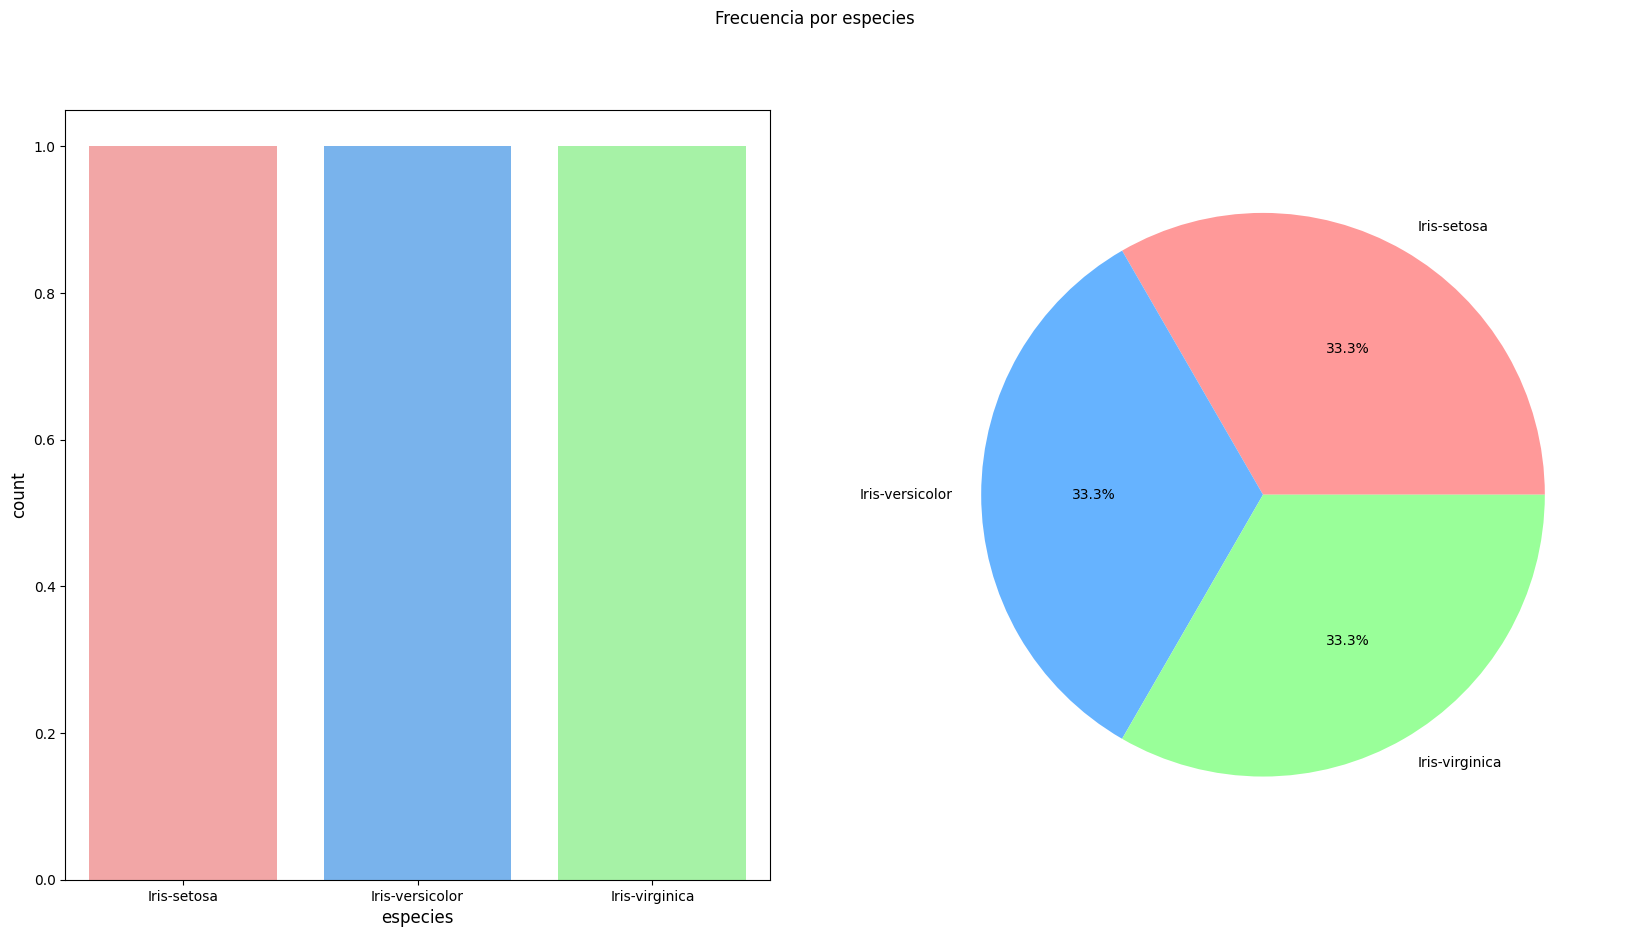

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
plt.suptitle(t='Frecuencia por especies')

# grafico de barras
sns.countplot(data=frecuencia_especies, palette=colores_especies, ax=ax[0])

colores_ordenados_por_frecuencia = [colores_especies[color_especie] for color_especie in frecuencia_especies.index]

# grafico de torta / proporciones
ax[1].pie(frecuencia_especies, autopct='%1.1f%%', labels=frecuencia_especies.index, colors=colores_ordenados_por_frecuencia)


plt.show()

### Observaciones de la etapa:

- **Valores unicos / Categorias:**
...

- **Valores nulos:**
...


## Exploración de columnas numéricas:

### Estadisticas descriptivas:

In [ ]:
# estadisticas sobre columnas numericas

df_limpio.describe()

,largo_sepalo_cm,ancho_sepalo_cm,largo_petalo_cm,ancho_petalo_cm,area_sepalo,area_petalo
count,150.00,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20,17.81,5.79
std,0.83,0.43,1.76,0.76,3.37,4.71
min,4.30,2.00,1.00,0.10,10.00,0.11
25%,5.10,2.80,1.60,0.30,15.64,0.42
50%,5.80,3.00,4.35,1.30,17.66,5.62
75%,6.40,3.30,5.10,1.80,20.32,9.69
max,7.90,4.40,6.90,2.50,30.02,15.87


### Histogramas de distribución:

1.   **largo_petalo_cm**

2.   **largo_sepalo_cm**

3.   **ancho_petalo_cm**

4.   **ancho_sepalo_cm**

5.   **area_sepalo**

6.   **area_petalo**


In [ ]:
cols_numericas_dist = ['largo_petalo_cm', 'largo_sepalo_cm', 'ancho_petalo_cm', 'ancho_sepalo_cm', 'area_sepalo', 'area_petalo']

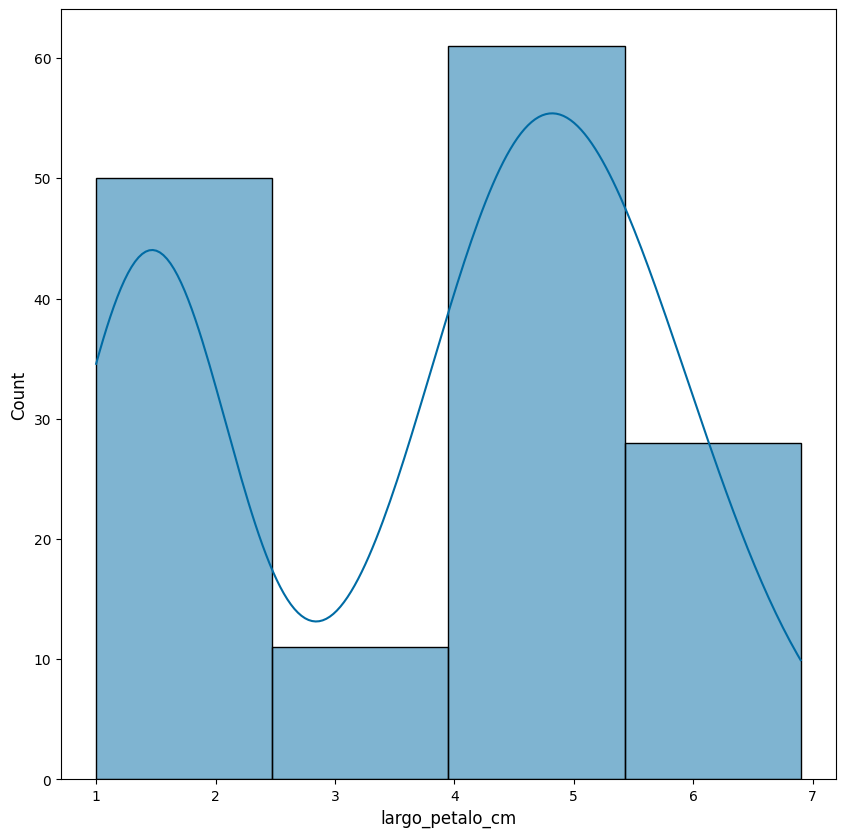

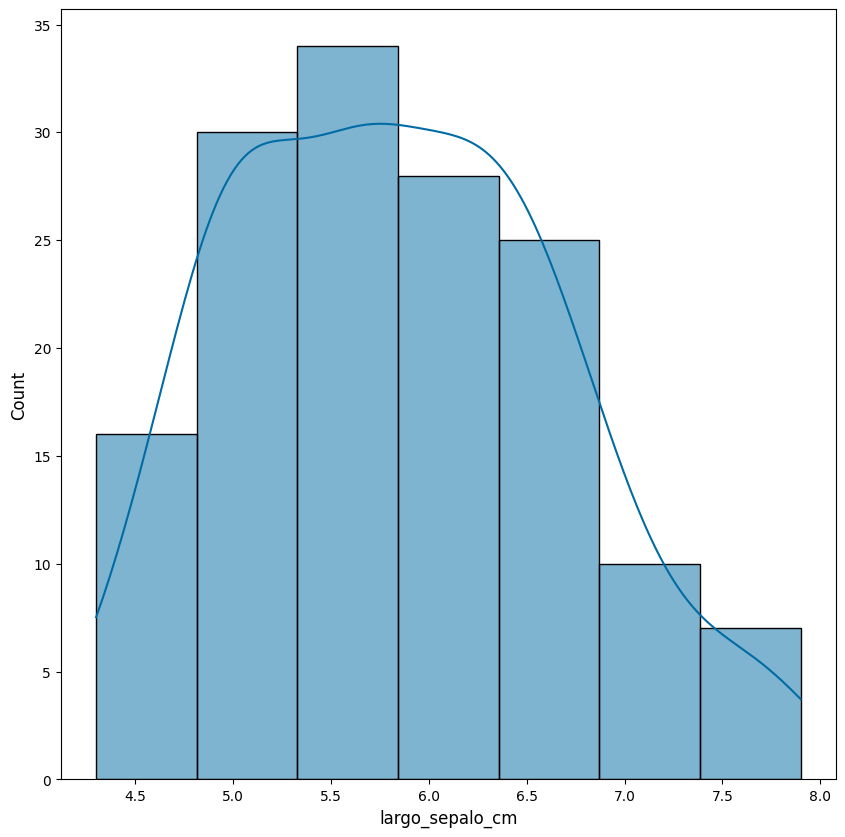

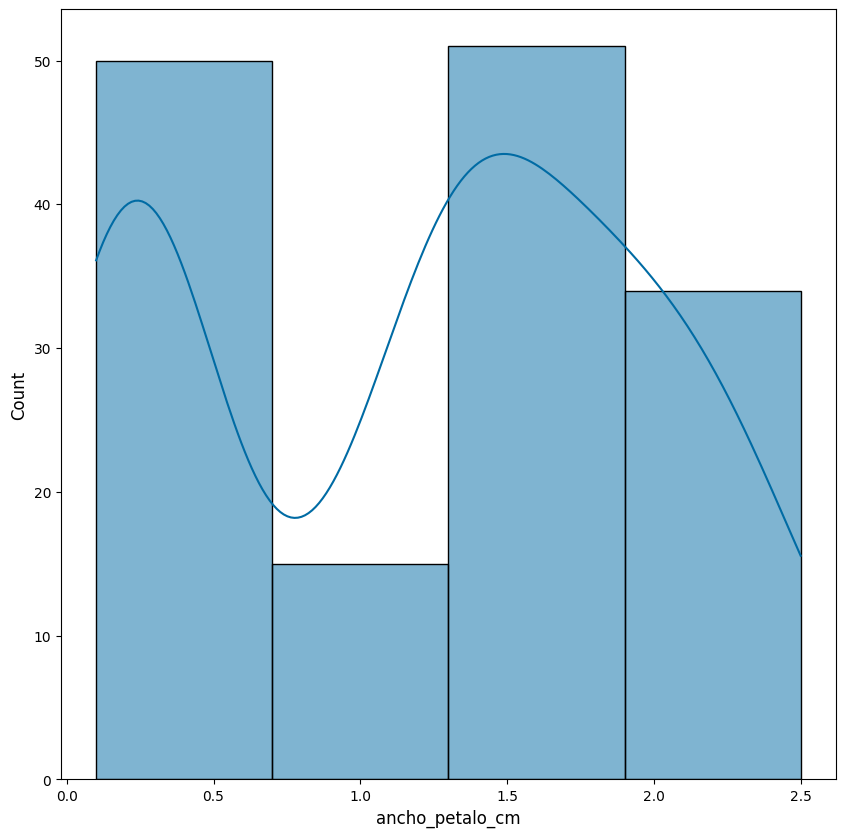

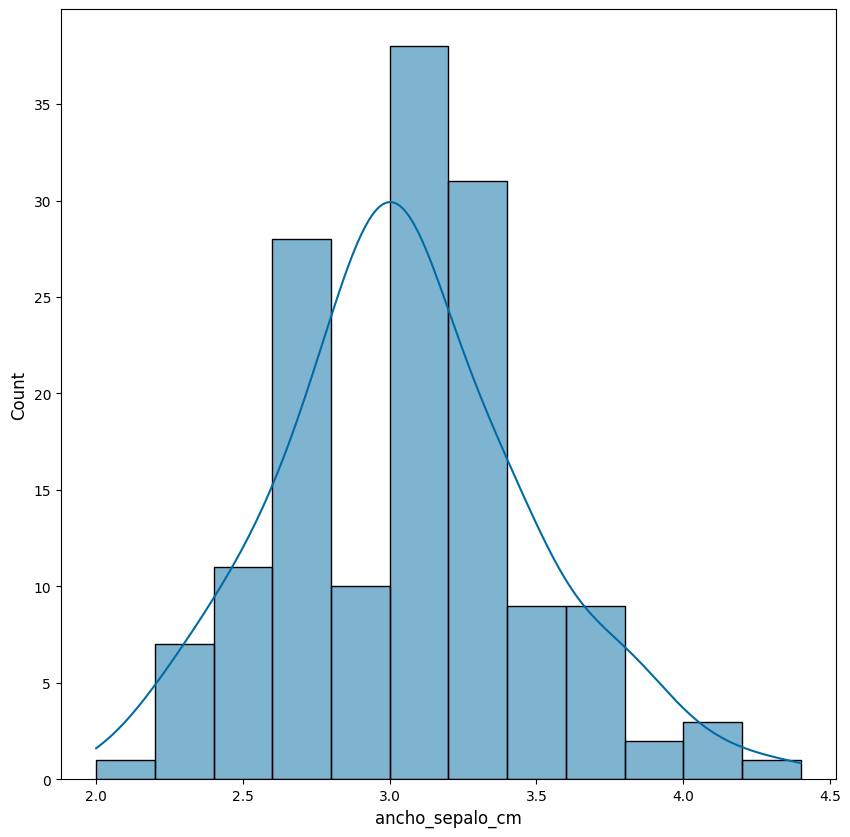

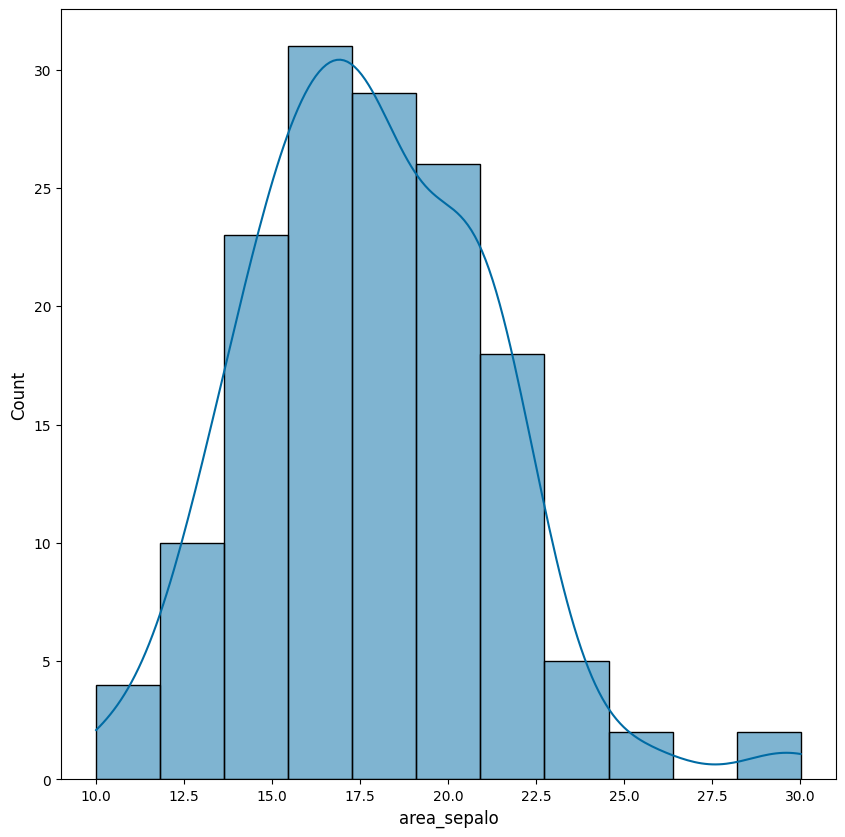

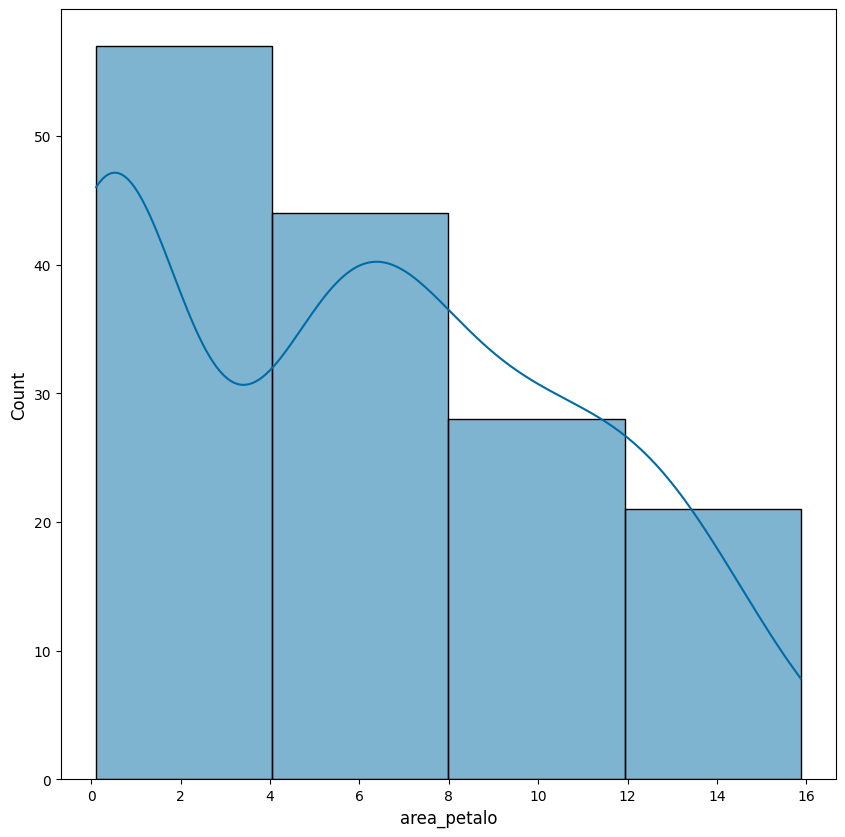

In [ ]:
# histograma con kde

for col_name in cols_numericas_dist:
  c_bins_lp = bins_calculator_fd(df=df_limpio, column=col_name)
  sns.histplot(data=df_limpio, x=col_name, kde=True, bins=c_bins_lp)
  plt.show()

  print()

### Outliers:

1.   **largo_petalo_cm**

2.   **largo_sepalo_cm**

3.   **ancho_petalo_cm**

4.   **ancho_sepalo_cm**

5.   **area_sepalo**

6.   **area_petalo**


In [ ]:
cols_numericas_outliers = ['largo_petalo_cm', 'largo_sepalo_cm', 'ancho_petalo_cm', 'ancho_sepalo_cm', 'area_sepalo', 'area_petalo']

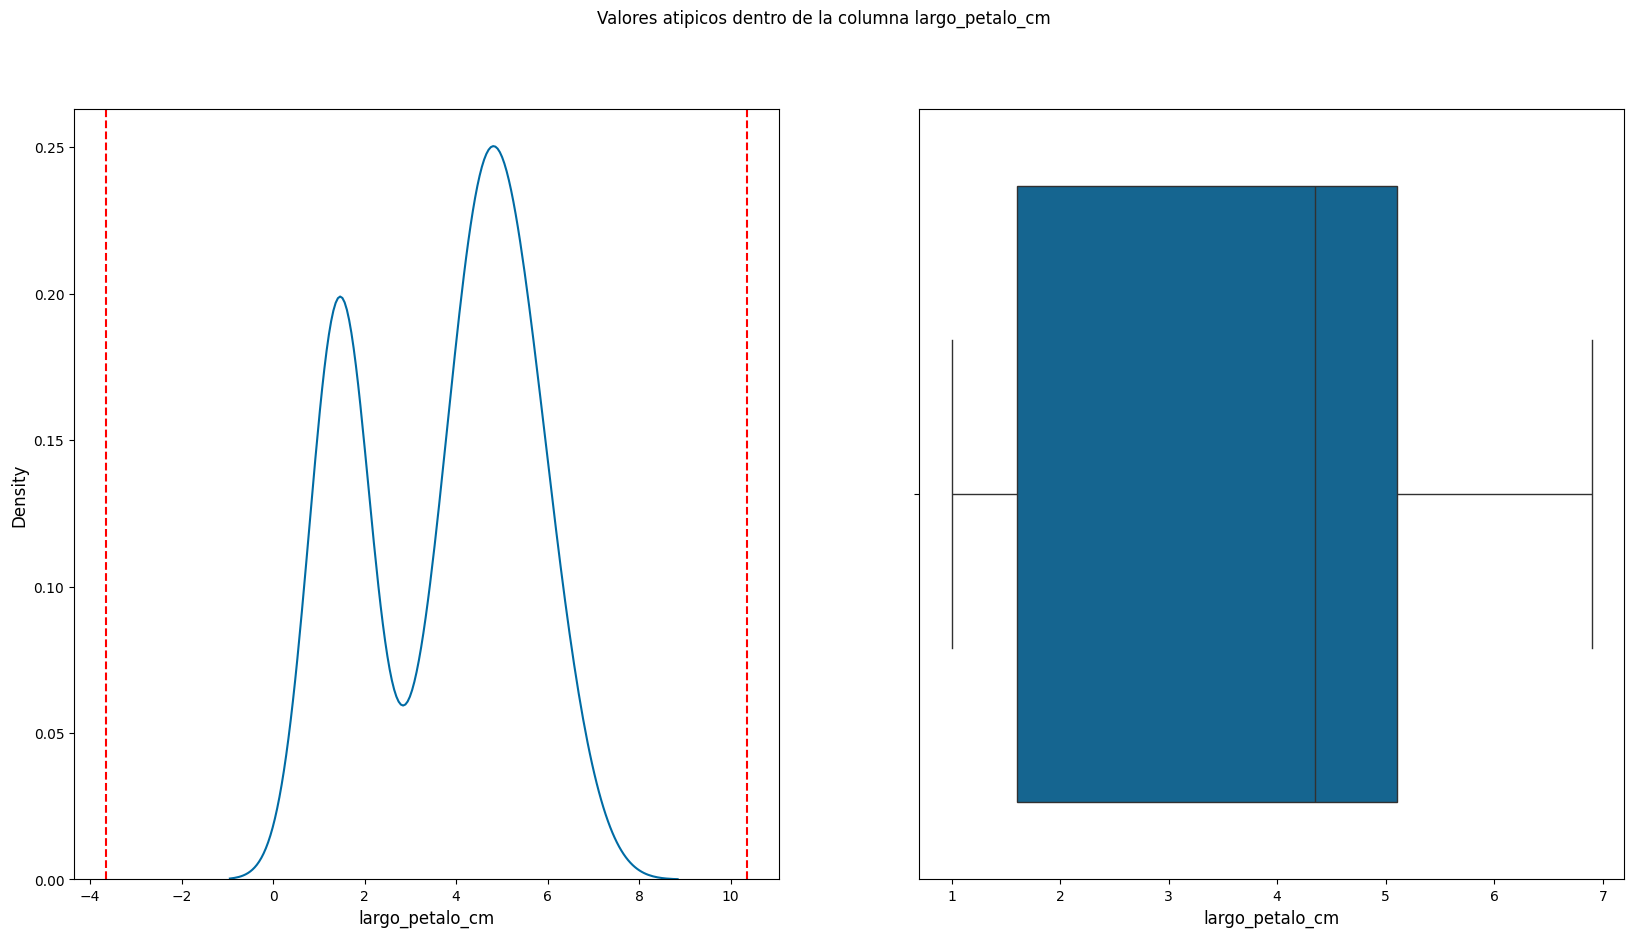

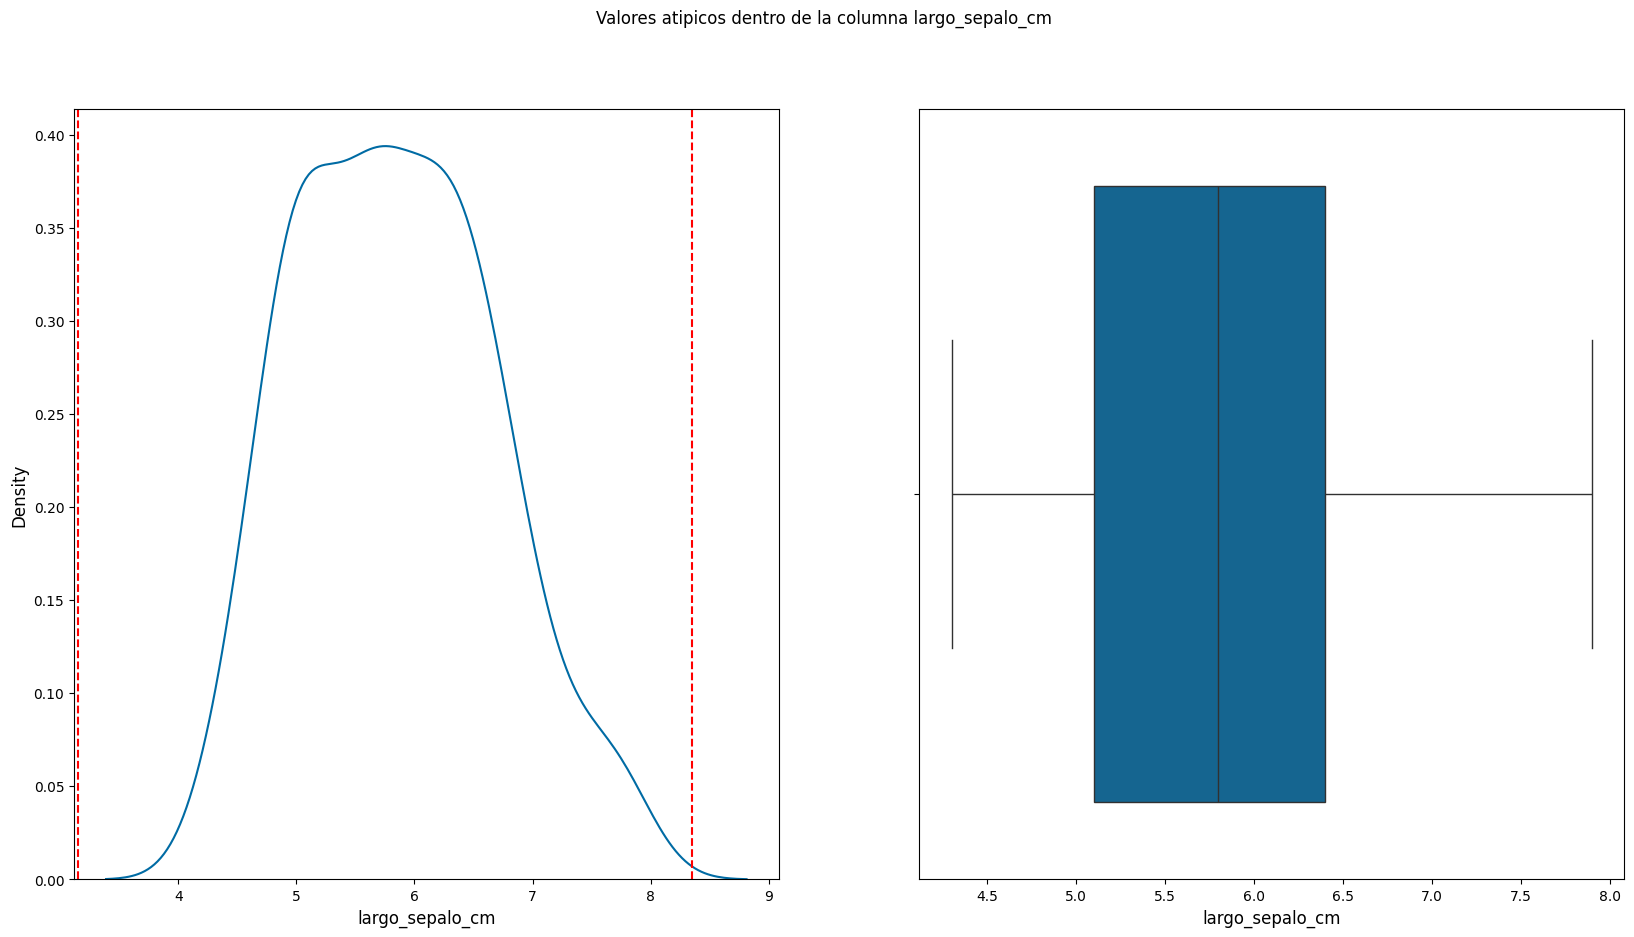

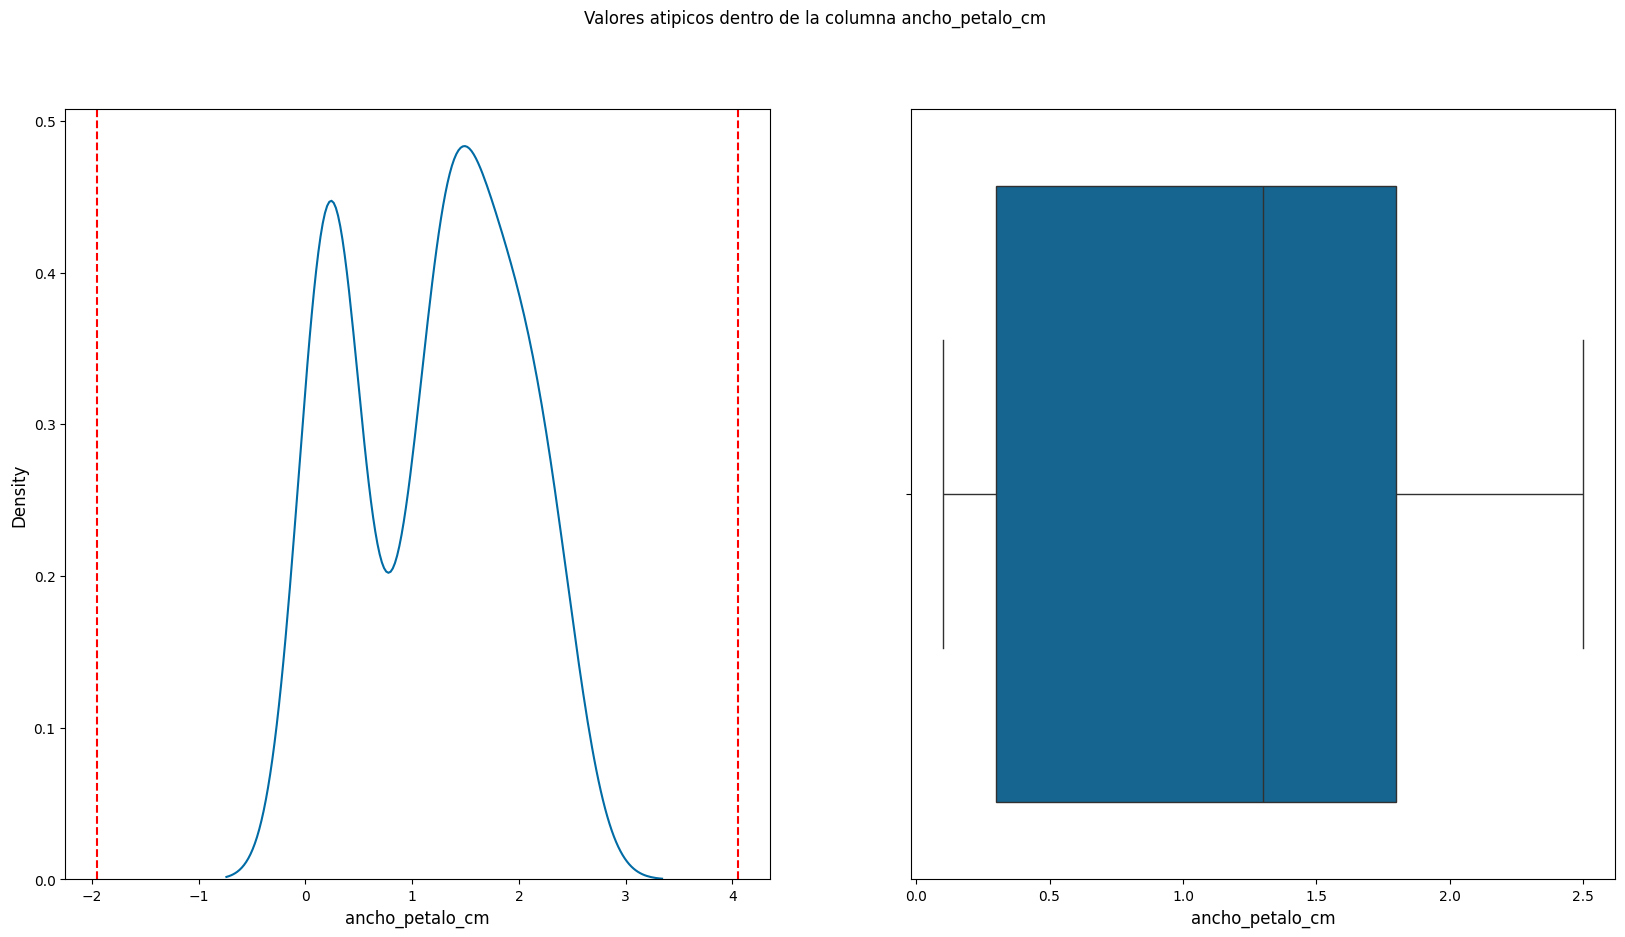

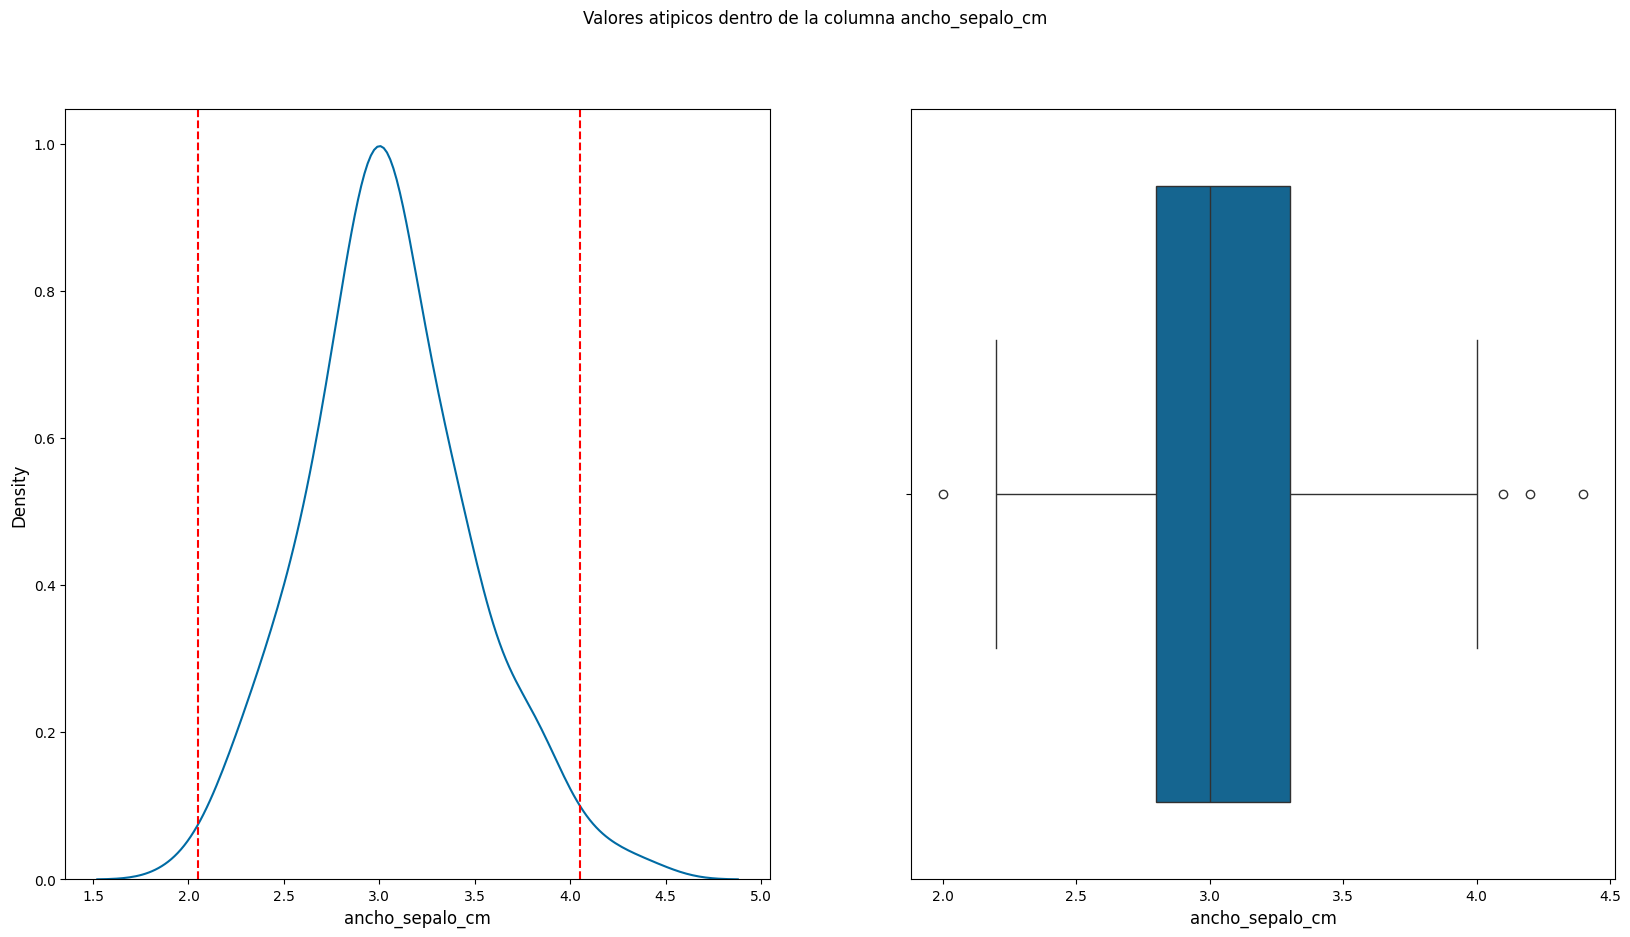

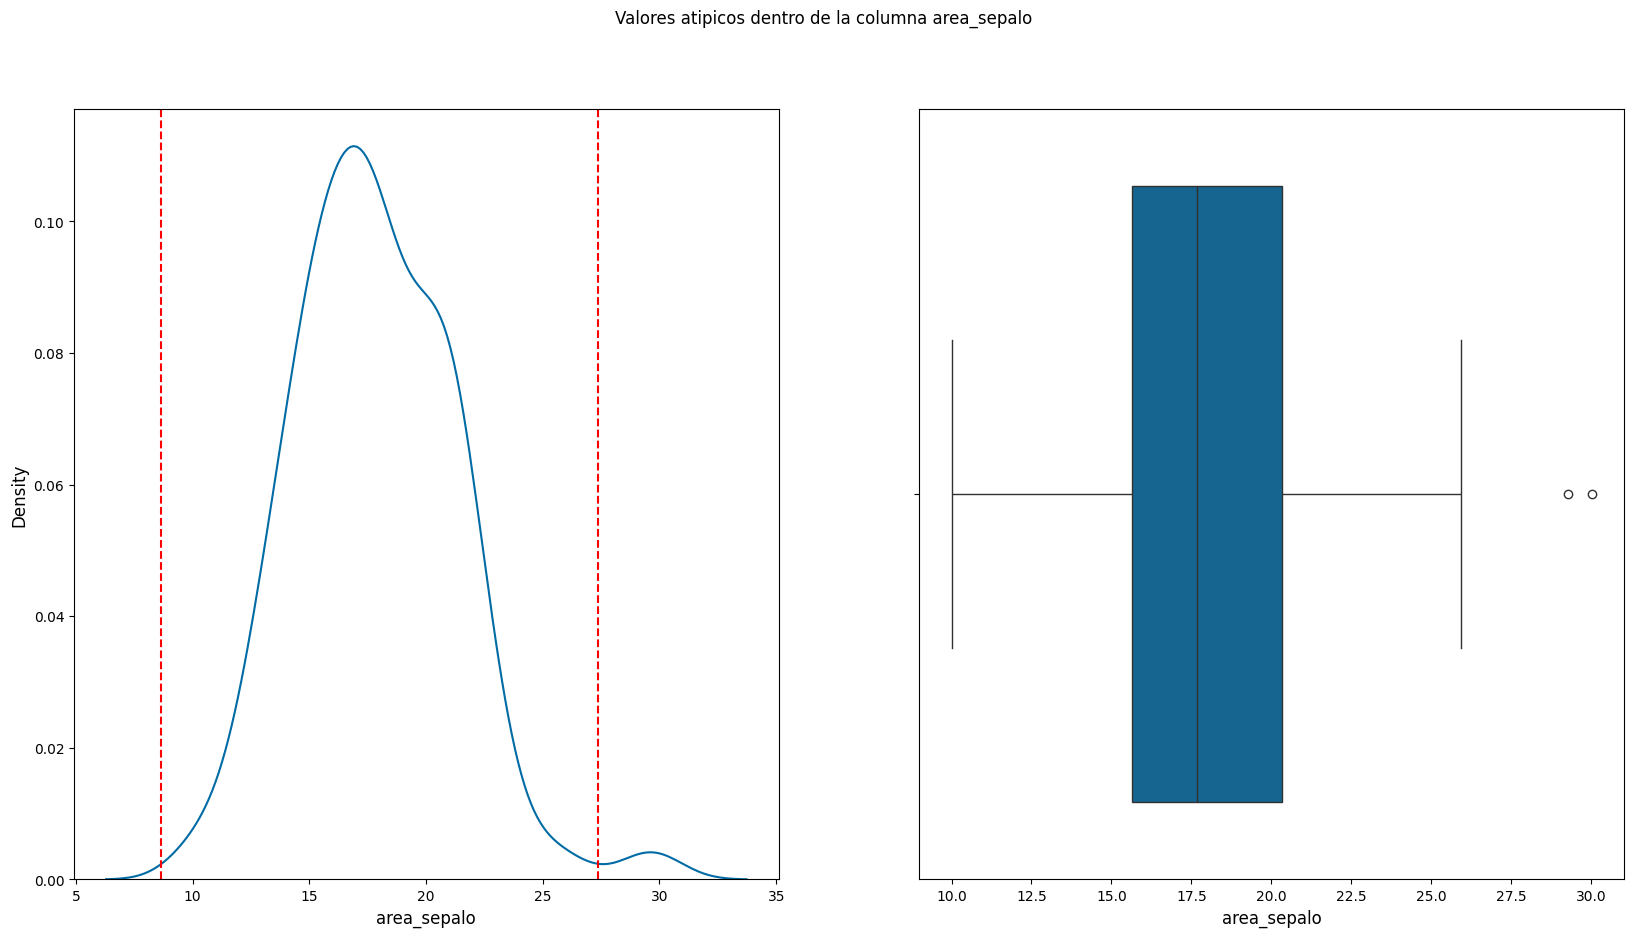

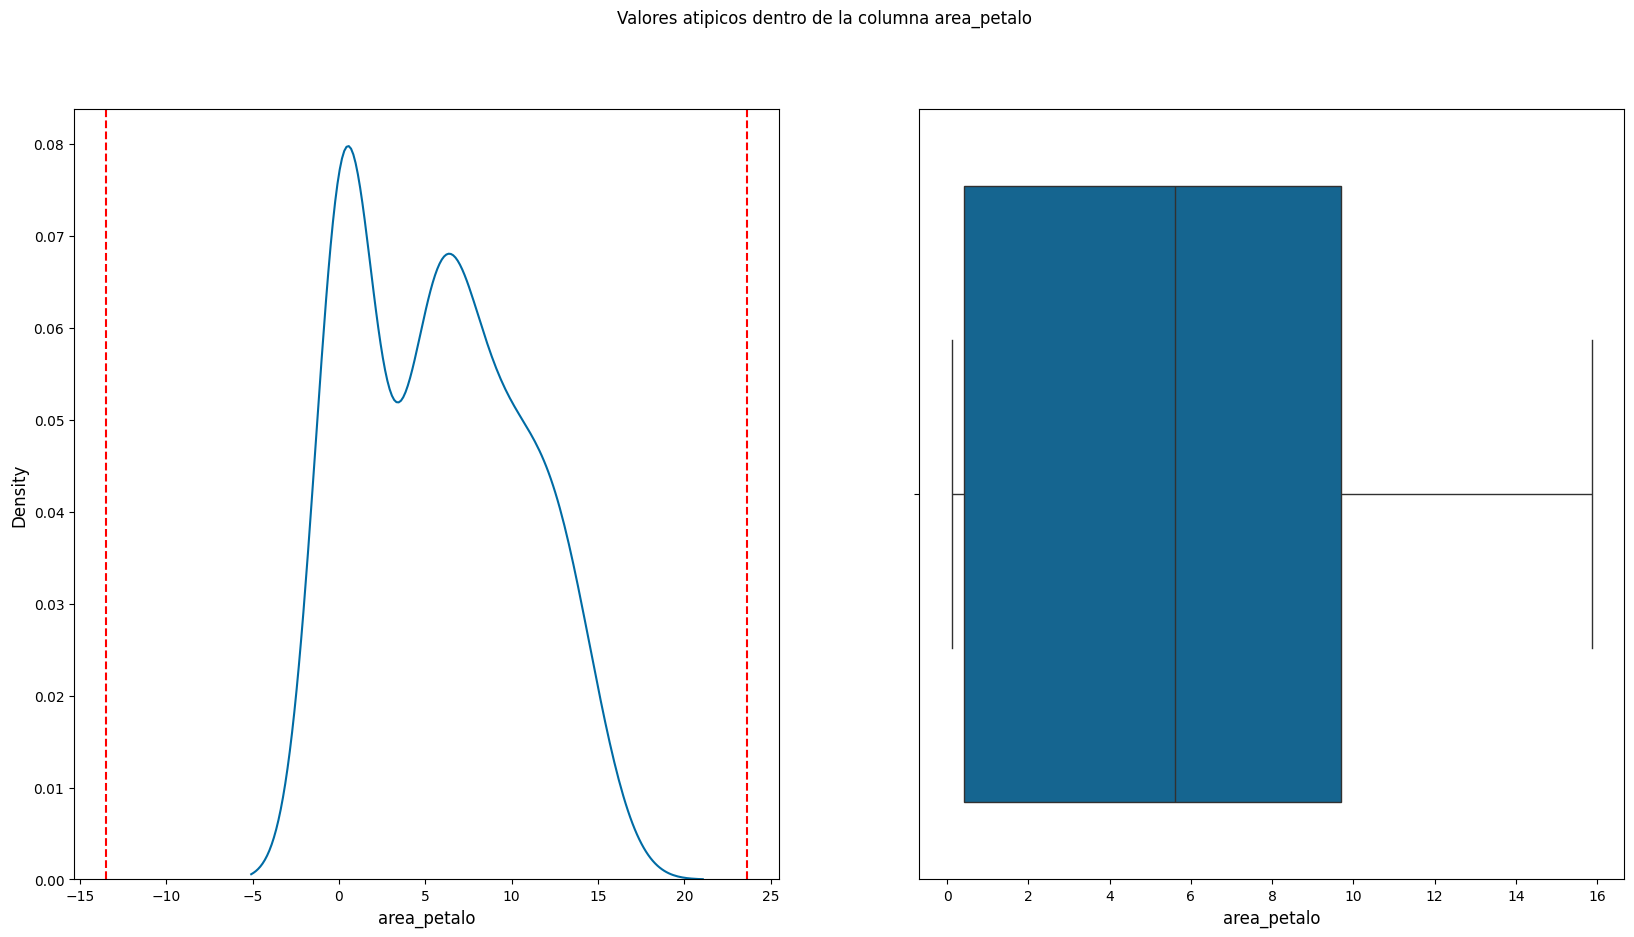

In [ ]:
for col_name in cols_numericas_outliers:
  limites_outliers = limite_outliers(df=df_limpio, column=col_name)

  fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(20, 10))
  plt.suptitle(t=f'Valores atipicos dentro de la columna {col_name}')

  # grafico kde
  sns.kdeplot(data=df_limpio[col_name], ax=ax[0])
  ax[0].axvline(x=limites_outliers['limite_inferior'], c='red', linestyle='dashed')
  ax[0].axvline(x=limites_outliers['limite_superior'], c='red', linestyle='dashed')

  # grafico de caja
  sns.boxplot(data=df_limpio, x=col_name, ax=ax[1])

  plt.show()

  print()

### Observaciones de la etapa:
- **Estadisticas descriptivas:**
....

- **Histogramas de distribución:**
...

- **Outliers o valores atipicos:**
...

## Analisis bivariable con distinción por la columna categórica 'especies'

Puede que estas estadisticas esten influenciadas por las diferentes especies?

In [ ]:
# groupby por especie mas describe
df_limpio.groupby(by=['especies'], as_index=False).describe()

especies largo_sepalo_cm                                    ancho_sepalo_cm                                \
                             count mean  std  min  25%  50%  75%  max           count mean  std  min  25%  50%  75%   
0      Iris-setosa           50.00 5.01 0.35 4.30 4.80 5.00 5.20 5.80           50.00 3.42 0.38 2.30 3.12 3.40 3.68   
1  Iris-versicolor           50.00 5.94 0.52 4.90 5.60 5.90 6.30 7.00           50.00 2.77 0.31 2.00 2.52 2.80 3.00   
2   Iris-virginica           50.00 6.59 0.64 4.90 6.22 6.50 6.90 7.90           50.00 2.97 0.32 2.20 2.80 3.00 3.18   

       largo_petalo_cm                                    ancho_petalo_cm                                     \
   max           count mean  std  min  25%  50%  75%  max           count mean  std  min  25%  50%  75%  max   
0 4.40           50.00 1.46 0.17 1.00 1.40 1.50 1.58 1.90           50.00 0.24 0.11 0.10 0.20 0.20 0.30 0.60   
1 3.40           50.00 4.26 0.47 3.00 4.00 4.35 4.60 5.10           50.00 1.33 0.20 1.00 1.20 1.30 1.50 1.80   
2 3.80           50.00 5.55 0.55 4.50 5.10 5.55 5.88 6.90           50.00 2.03 0.27 1.40 1.80 2.00 2.30 2.50   

  area_sepalo                                          area_petalo                                         
        count  mean  std   min   25%   50%   75%   max       count  mean  std  min  25%   50%   75%   max  
0       50.00 17.21 2.95 10.35 15.04 17.00 19.16 25.08       50.00  0.36 0.18 0.11 0.27  0.30  0.42  0.96  
1       50.00 16.53 2.87 10.00 14.35 16.38 18.49 22.40       50.00  5.72 1.37 3.30 4.86  5.62  6.75  8.64  
2       50.00 19.68 3.46 12.25 17.43 20.06 21.41 30.02       50.00 11.30 2.16 7.50 9.72 11.45 12.79 15.87

### Histogramas de distribución:

1.   **largo_petalo_cm**

2.   **largo_sepalo_cm**

3.   **ancho_petalo_cm**

4.   **ancho_sepalo_cm**

5.   **area_sepalo**

6.   **area_petalo**


In [ ]:
# df para especie 'Iris-setosa'
mask_hue_setosa = df_limpio['especies'] == 'Iris-setosa'
df_limpio_setosa = df_limpio[mask_hue_setosa]

In [ ]:
# df para especie 'Iris-versicolor'
mask_hue_versicolor= df_limpio['especies'] == 'Iris-versicolor'
df_limpio_versicolor = df_limpio[mask_hue_versicolor]

In [ ]:
# df para especie 'Iris-virginica'
mask_hue_virginica = df_limpio['especies'] == 'Iris-virginica'
df_limpio_virginica = df_limpio[mask_hue_virginica]

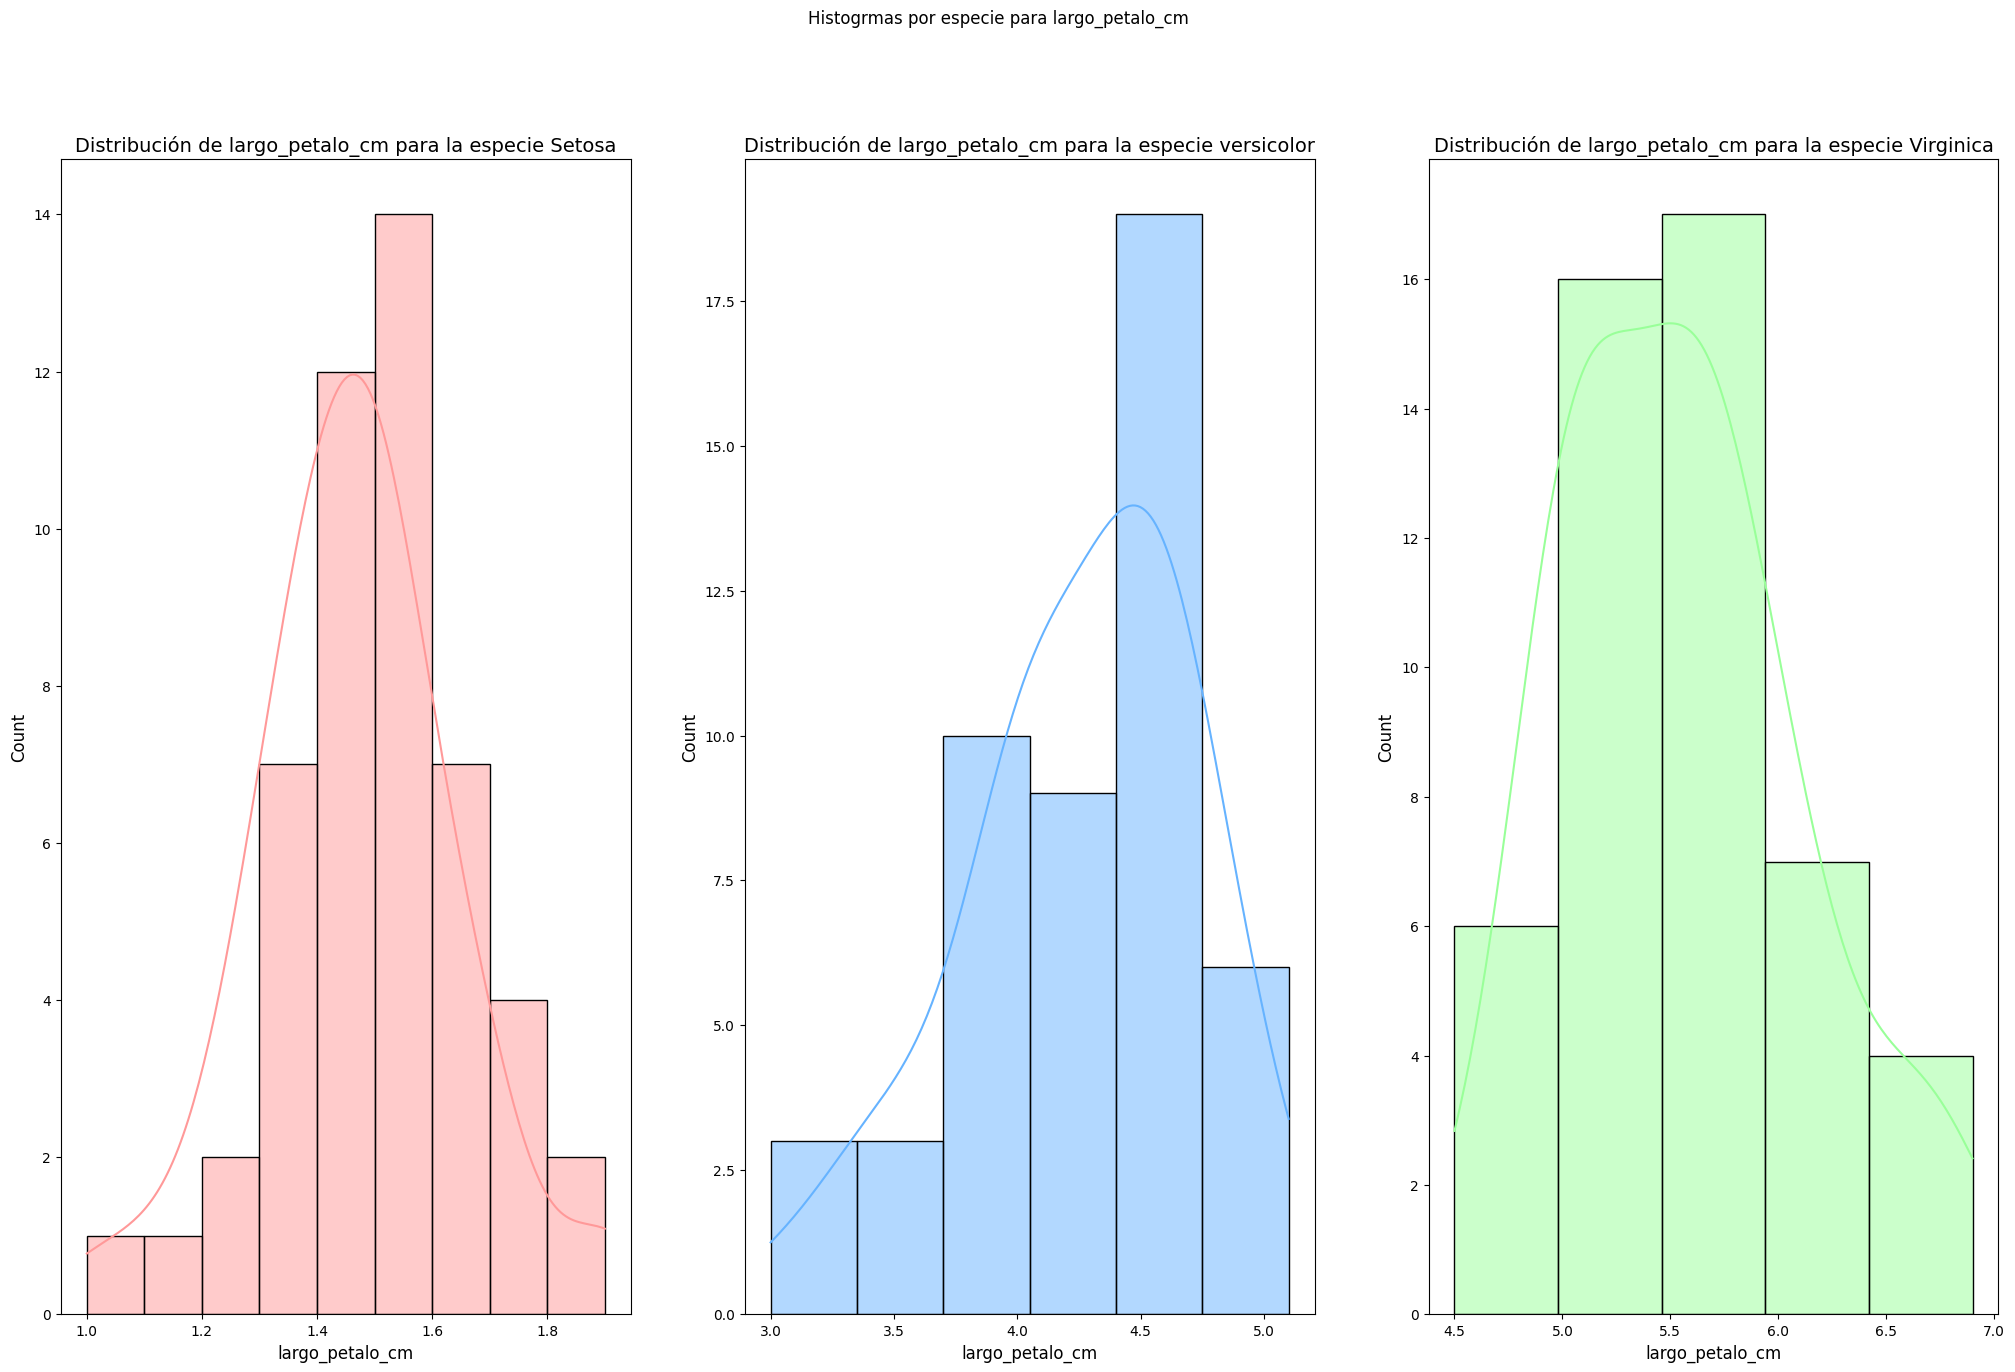

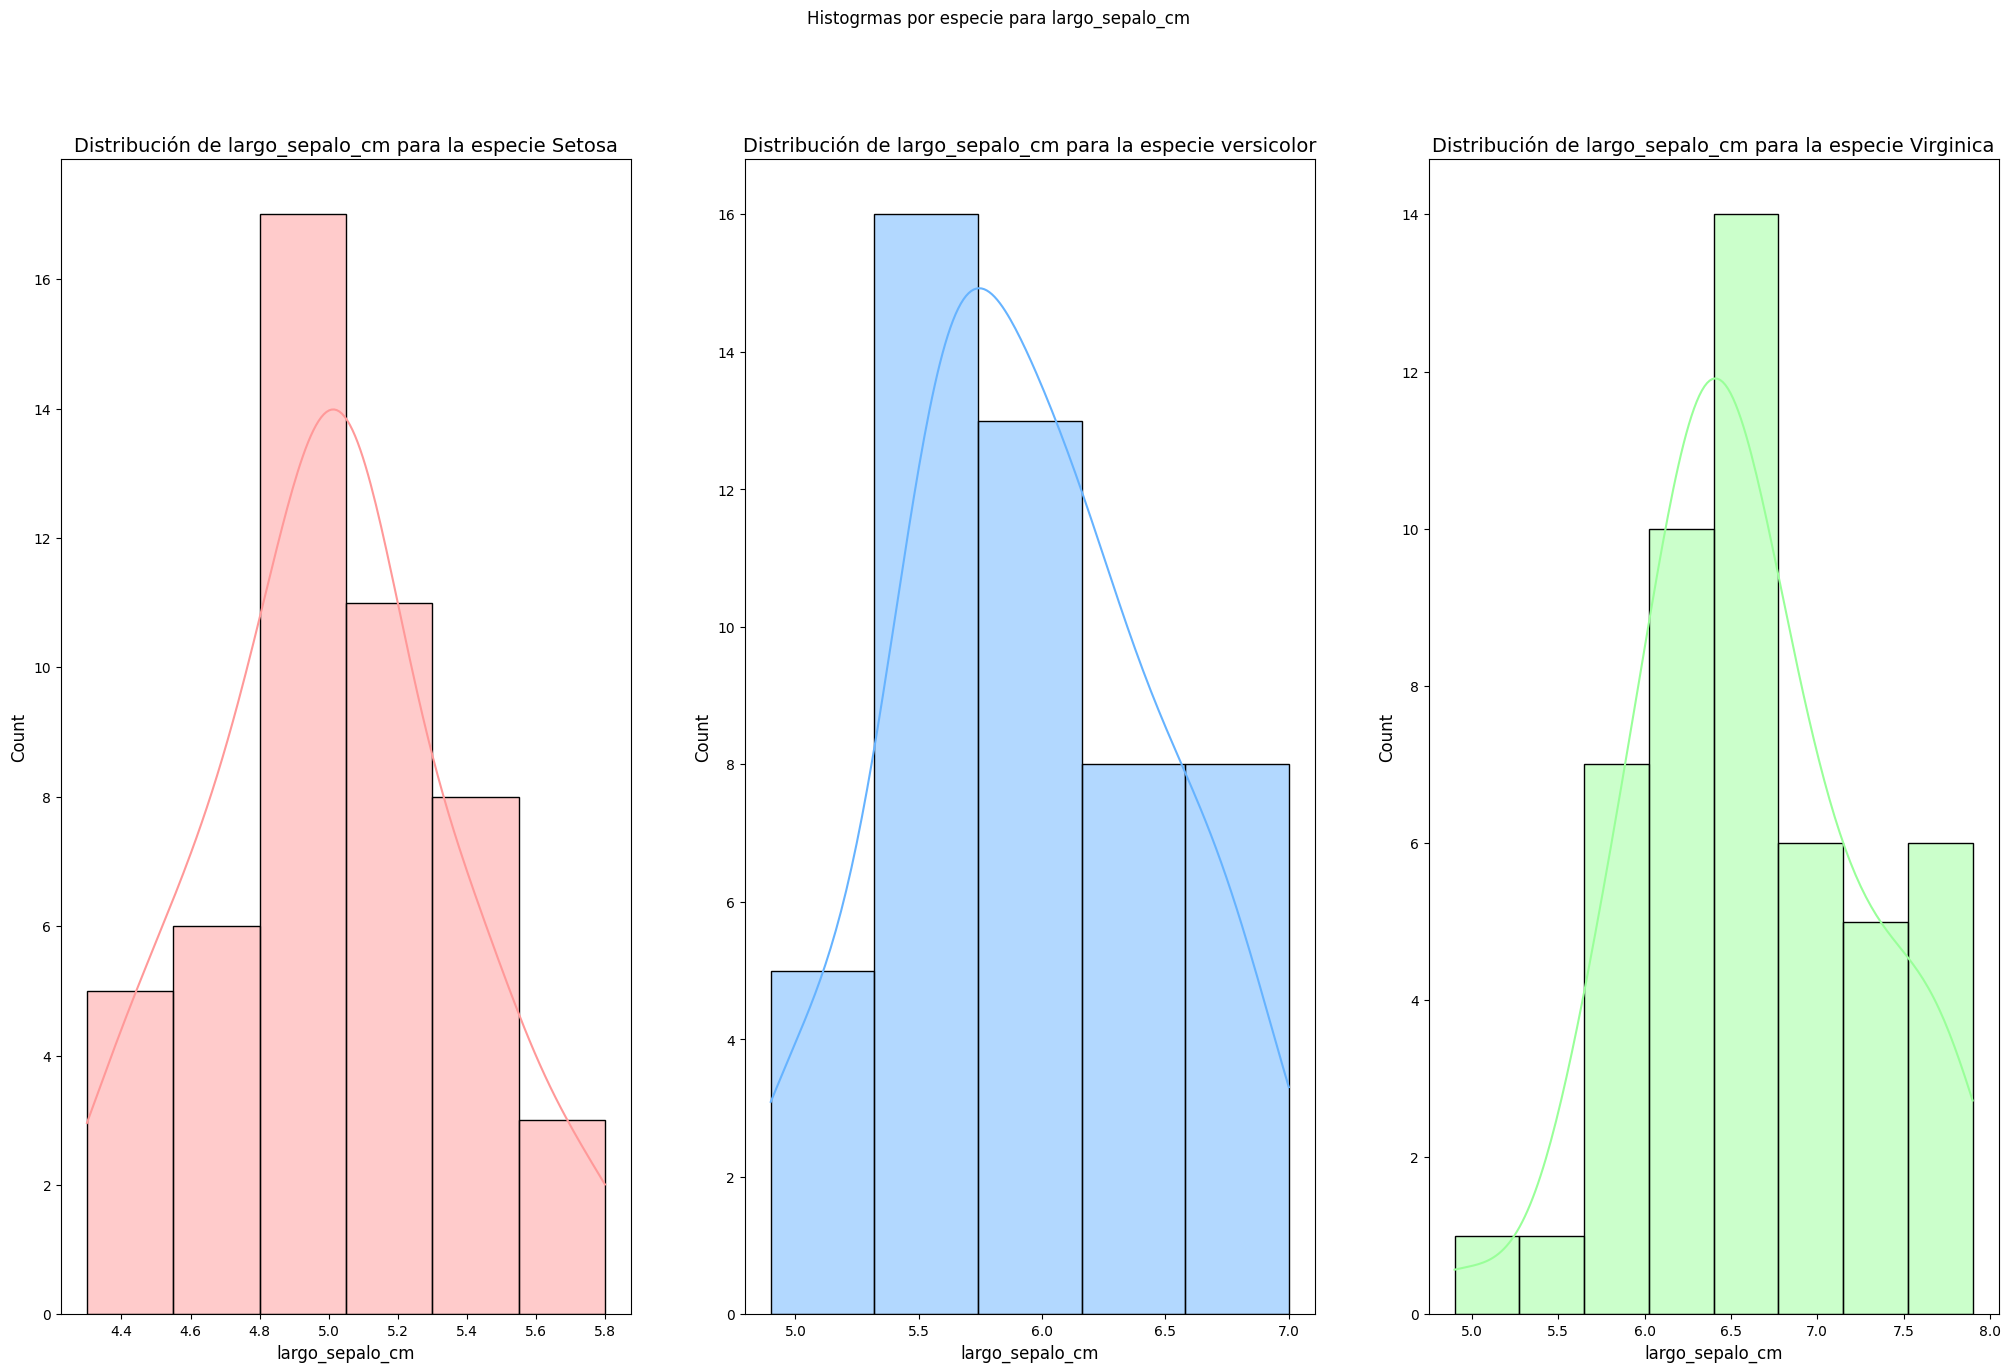

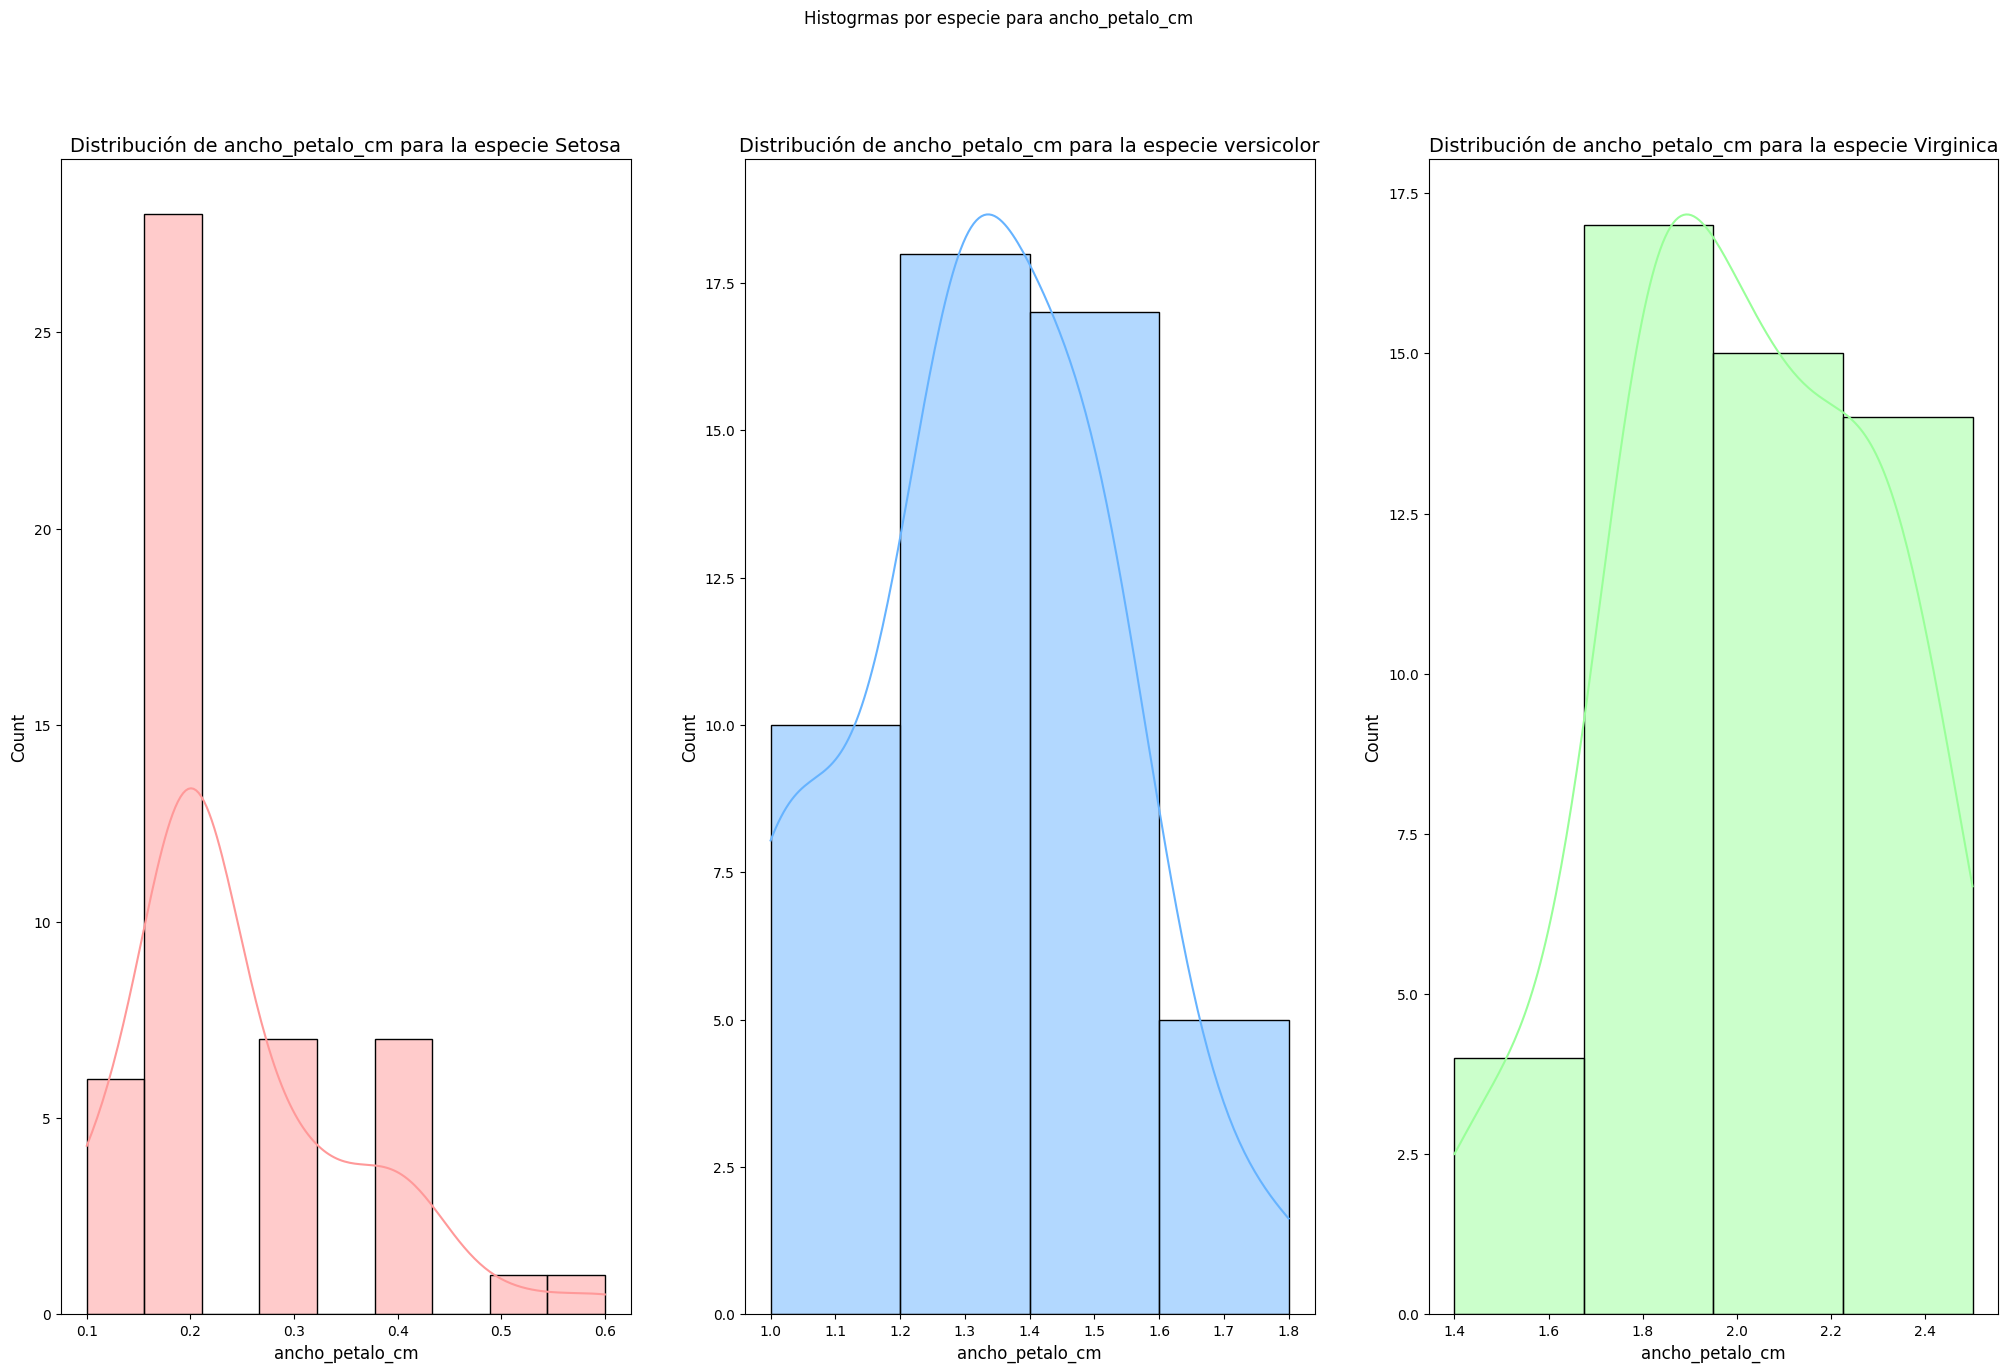

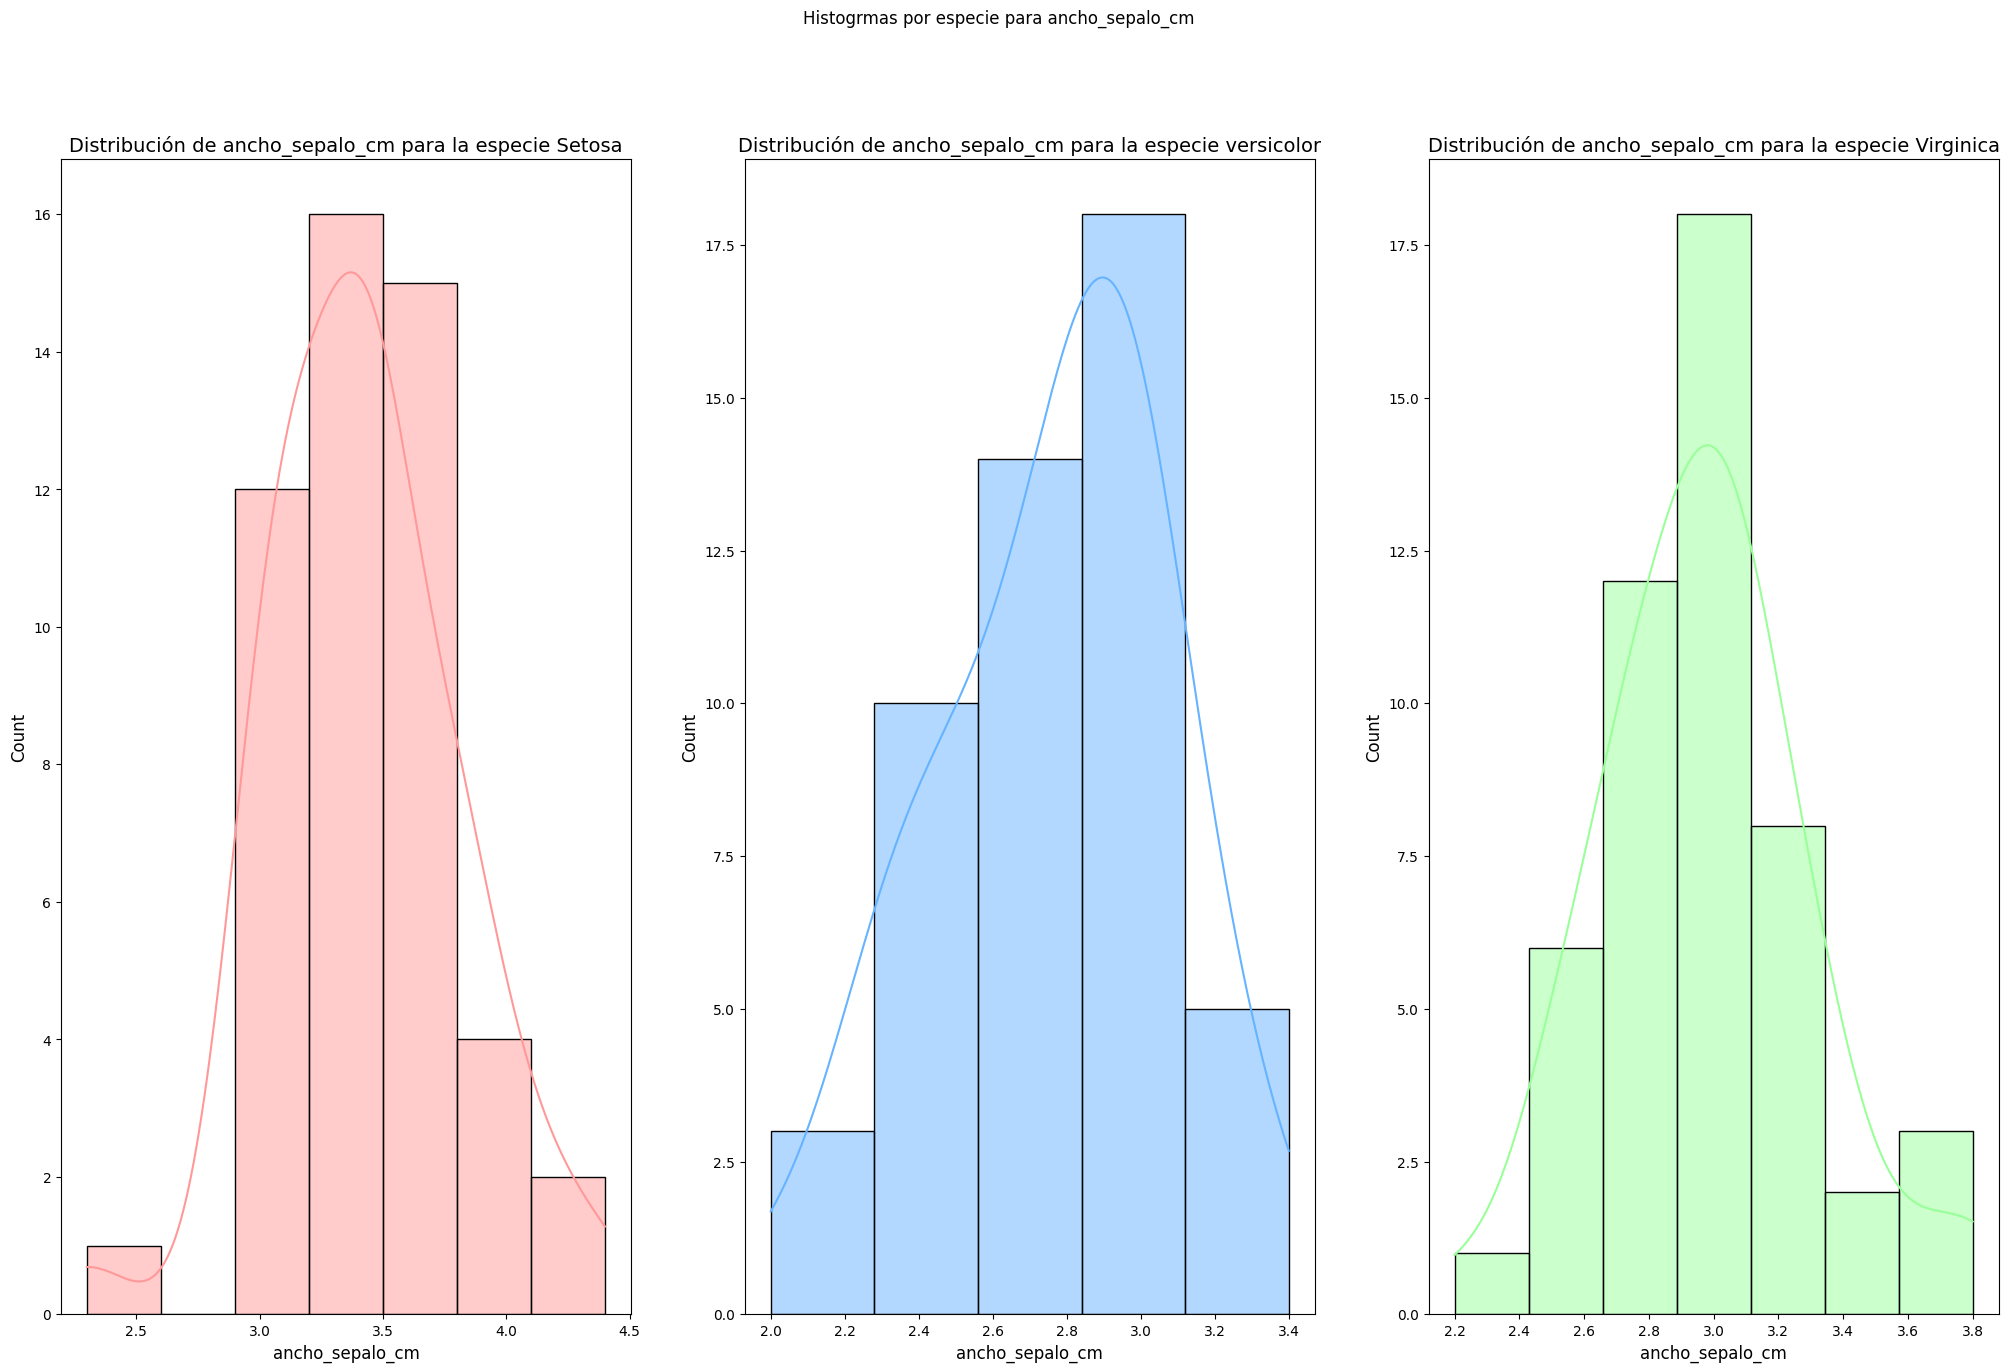

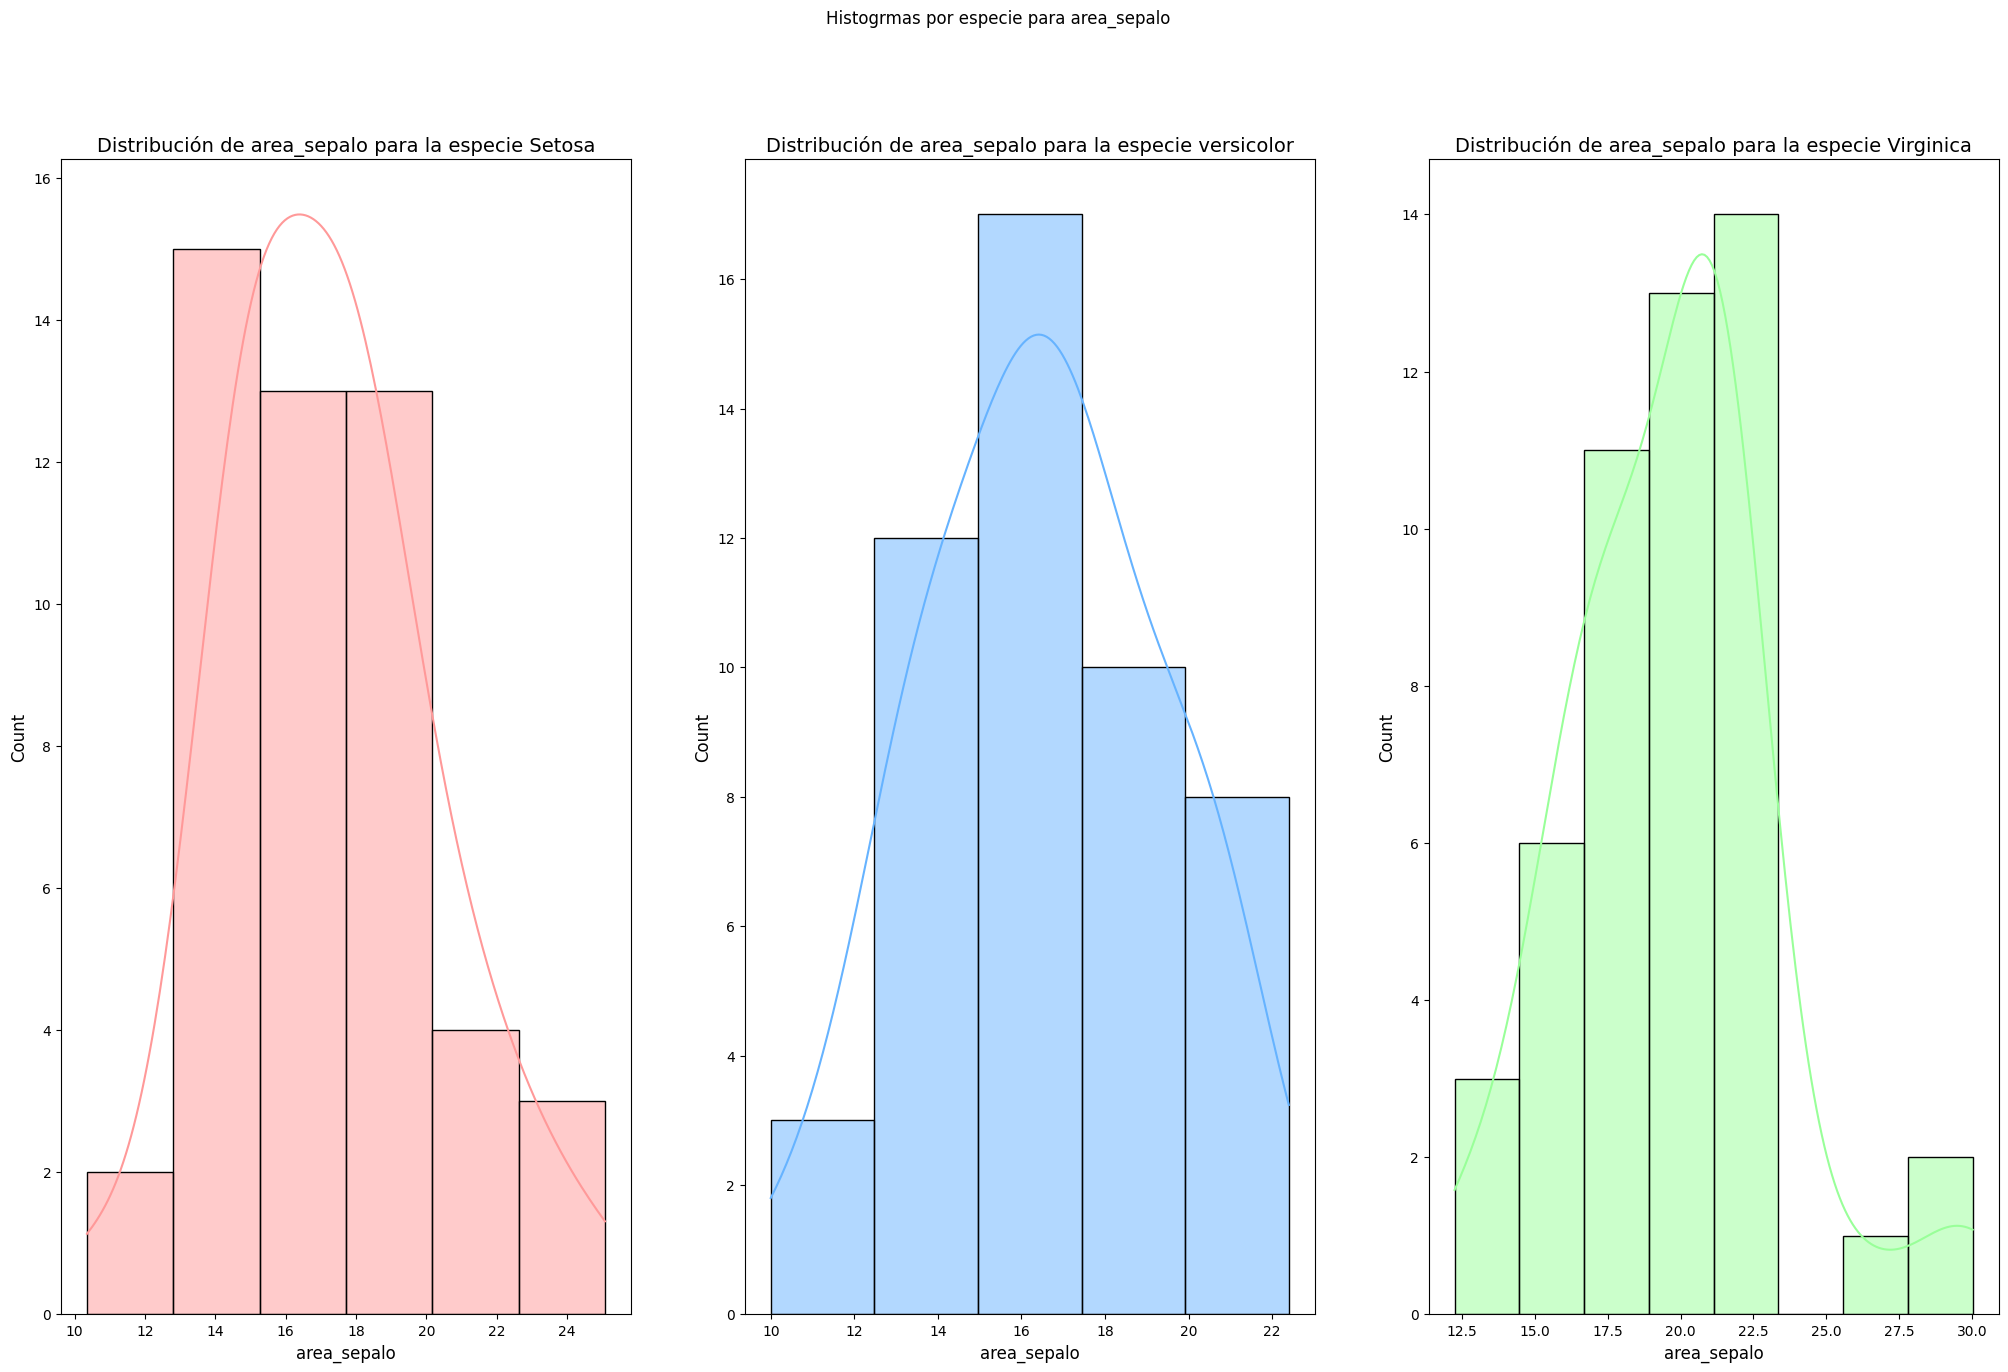

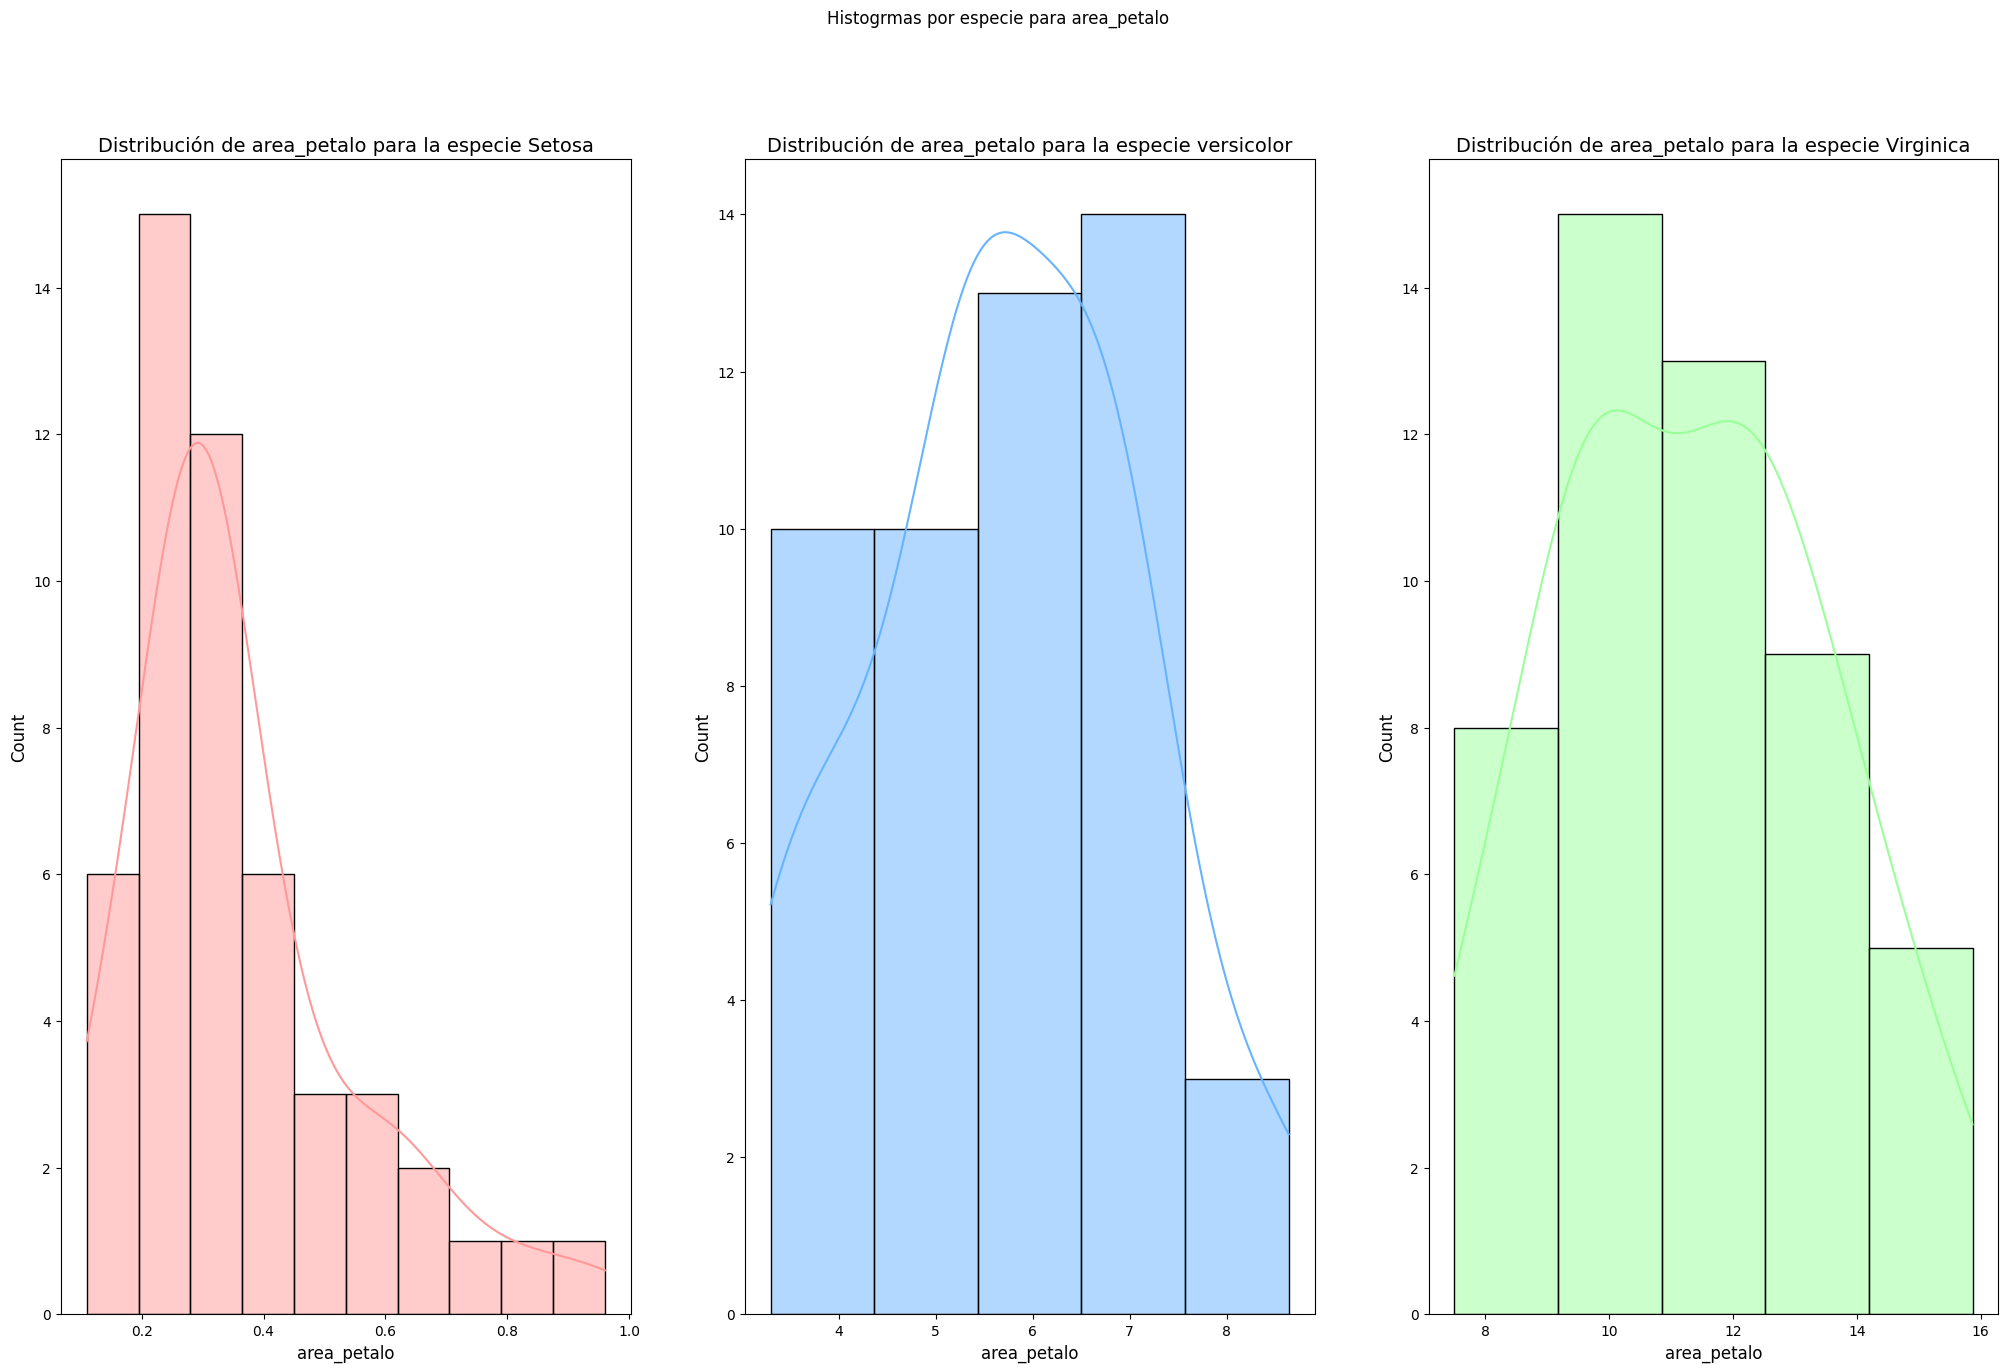

In [ ]:
cols_numericas_dist = ['largo_petalo_cm', 'largo_sepalo_cm', 'ancho_petalo_cm', 'ancho_sepalo_cm', 'area_sepalo', 'area_petalo']

for col_name in cols_numericas_dist:
  fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(25, 15))
  plt.suptitle(t=f'Histogrmas por especie para {col_name}')

  # histograma con kde para 'Iris-setosa'
  c_bins_lp_setosa = bins_calculator_fd(df=df_limpio_setosa, column=col_name)
  sns.histplot(data=df_limpio_setosa, x=col_name, kde=True, bins=c_bins_lp_setosa, ax=ax[0], color=colores_especies['Iris-setosa'])
  ax[0].set_title(f'Distribución de {col_name} para la especie Setosa')

  # histograma con kde para 'Iris-versicolor'
  c_bins_lp_versicolor = bins_calculator_fd(df=df_limpio_versicolor, column=col_name)
  sns.histplot(data=df_limpio_versicolor, x=col_name, kde=True, bins=c_bins_lp_versicolor, ax=ax[1], color=colores_especies['Iris-versicolor'])
  ax[1].set_title(f'Distribución de {col_name} para la especie versicolor')

  # histograma con kde para 'Iris-virginica'
  c_bins_lp_virginica = bins_calculator_fd(df=df_limpio_virginica, column=col_name)
  sns.histplot(data=df_limpio_virginica, x=col_name, kde=True, bins=c_bins_lp_virginica, ax=ax[2], color=colores_especies['Iris-virginica'])
  ax[2].set_title(f'Distribución de {col_name} para la especie Virginica')

  plt.show()

  print()

### Outliers:


1.   **largo_petalo_cm**

2.   **largo_sepalo_cm**

3.   **ancho_petalo_cm**

4.   **ancho_sepalo_cm**

5.   **area_sepalo**

6.   **area_petalo**

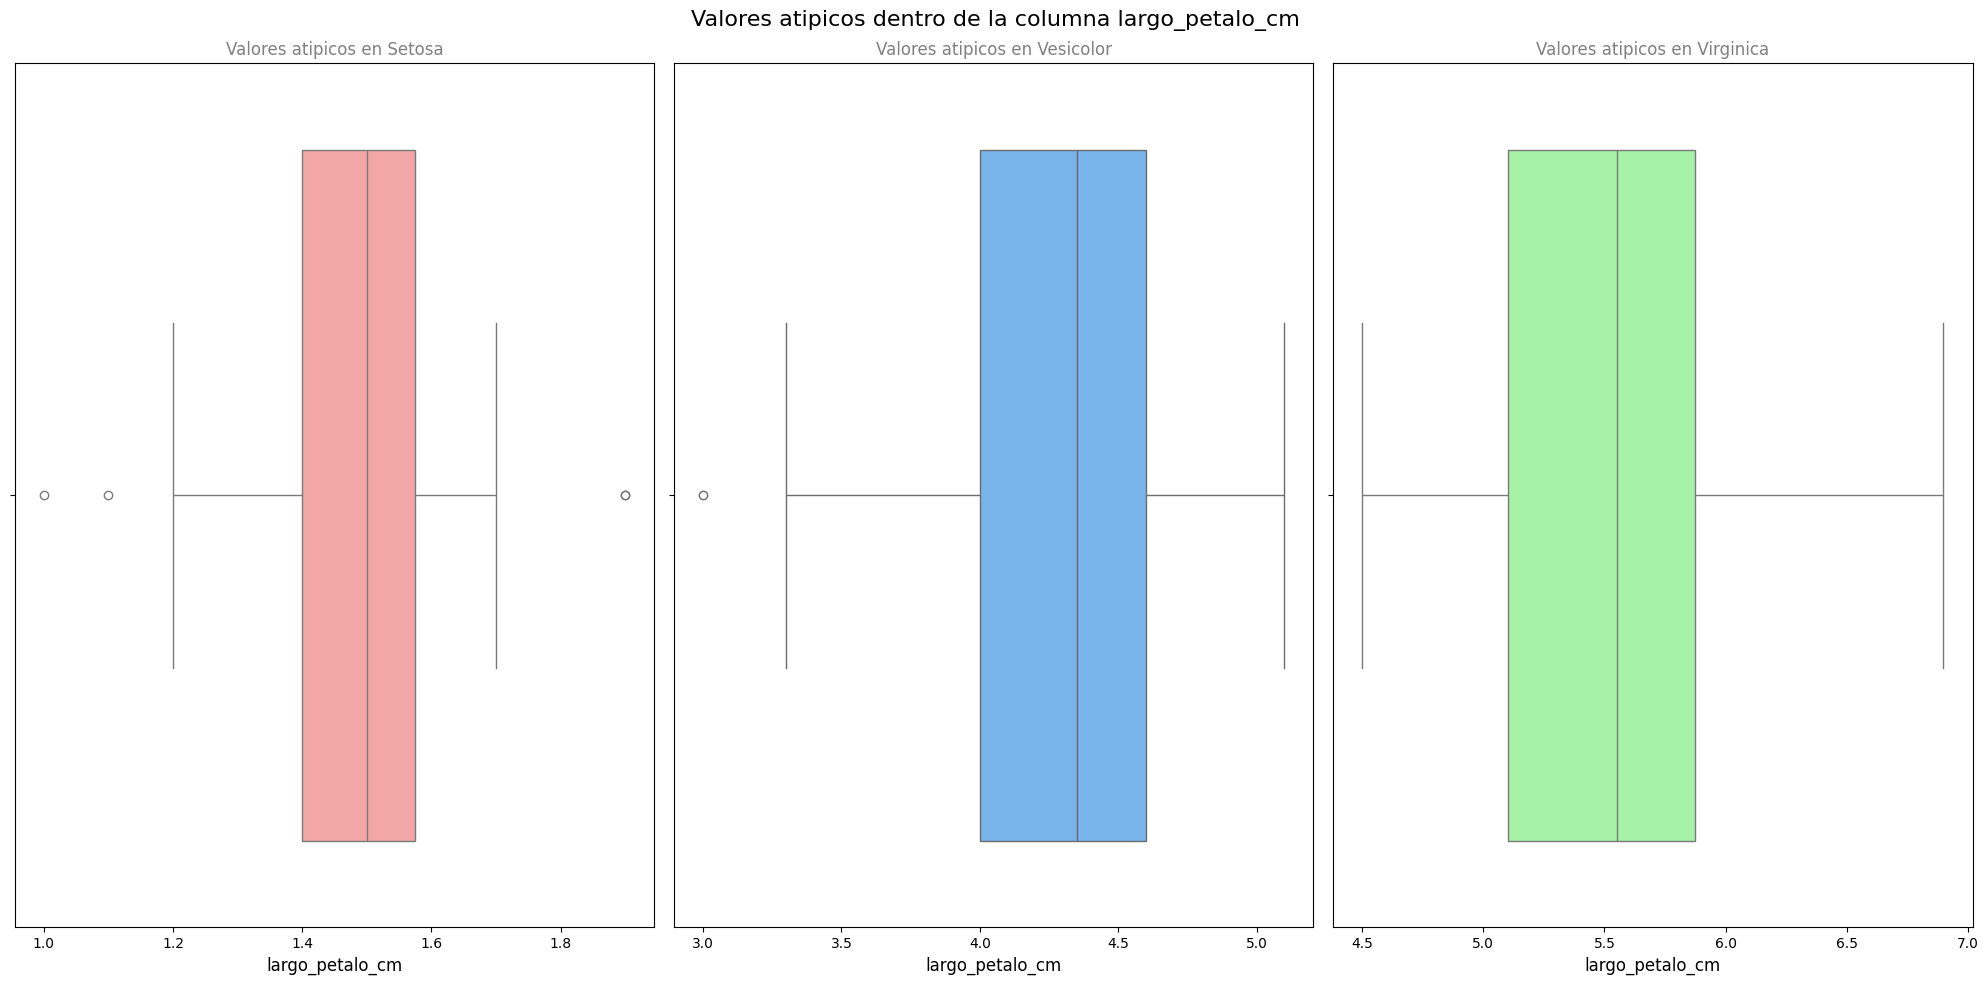

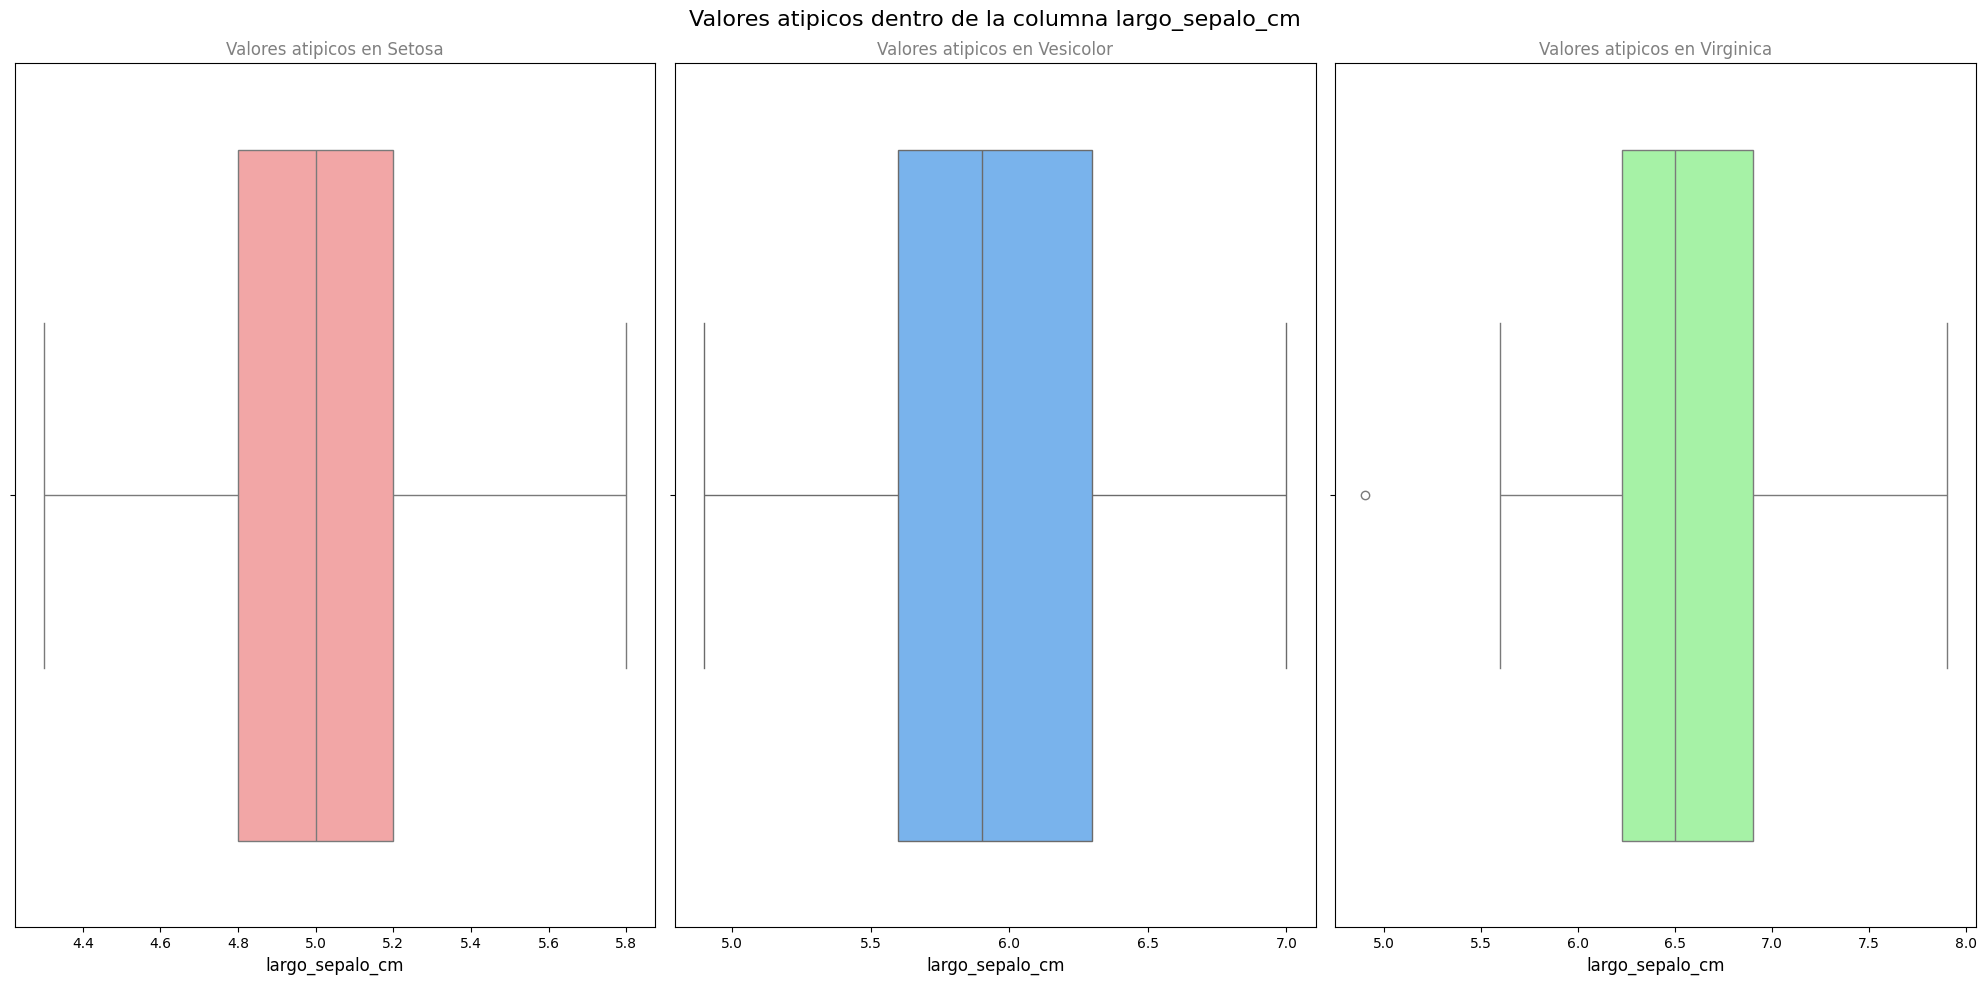

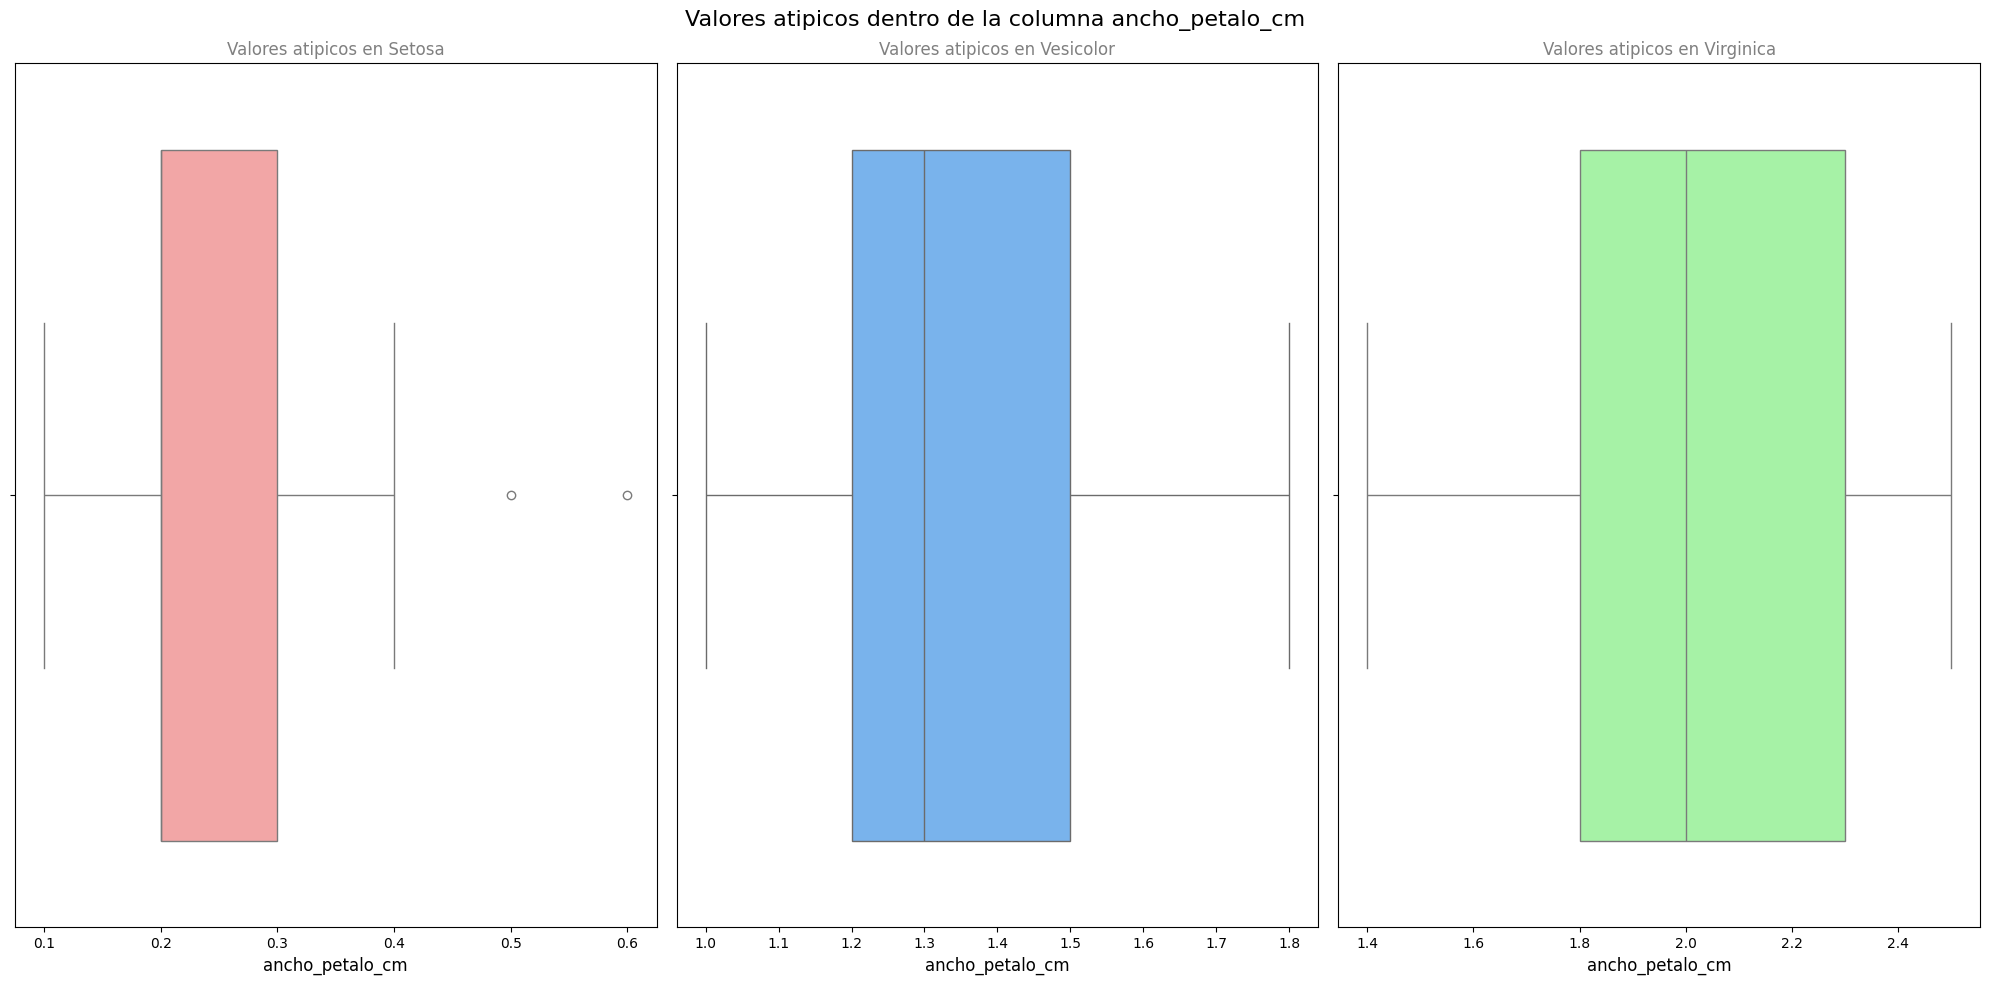

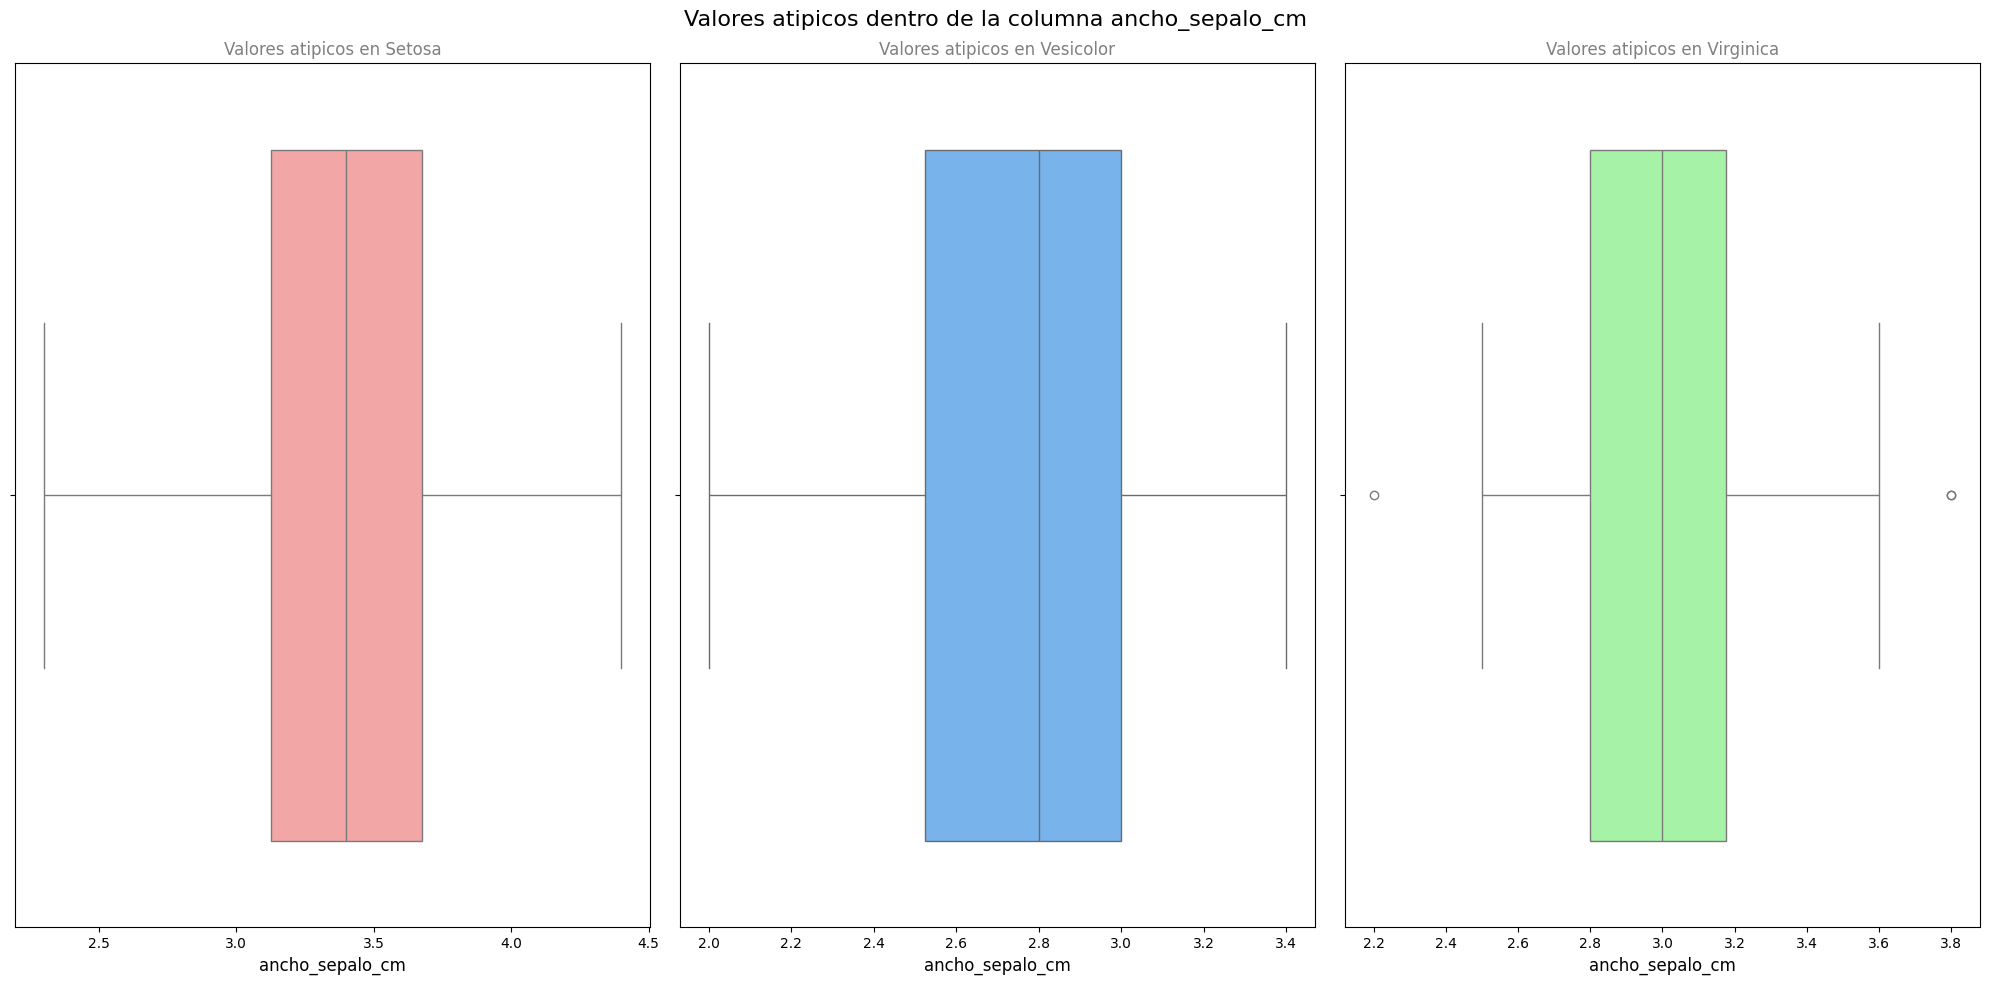

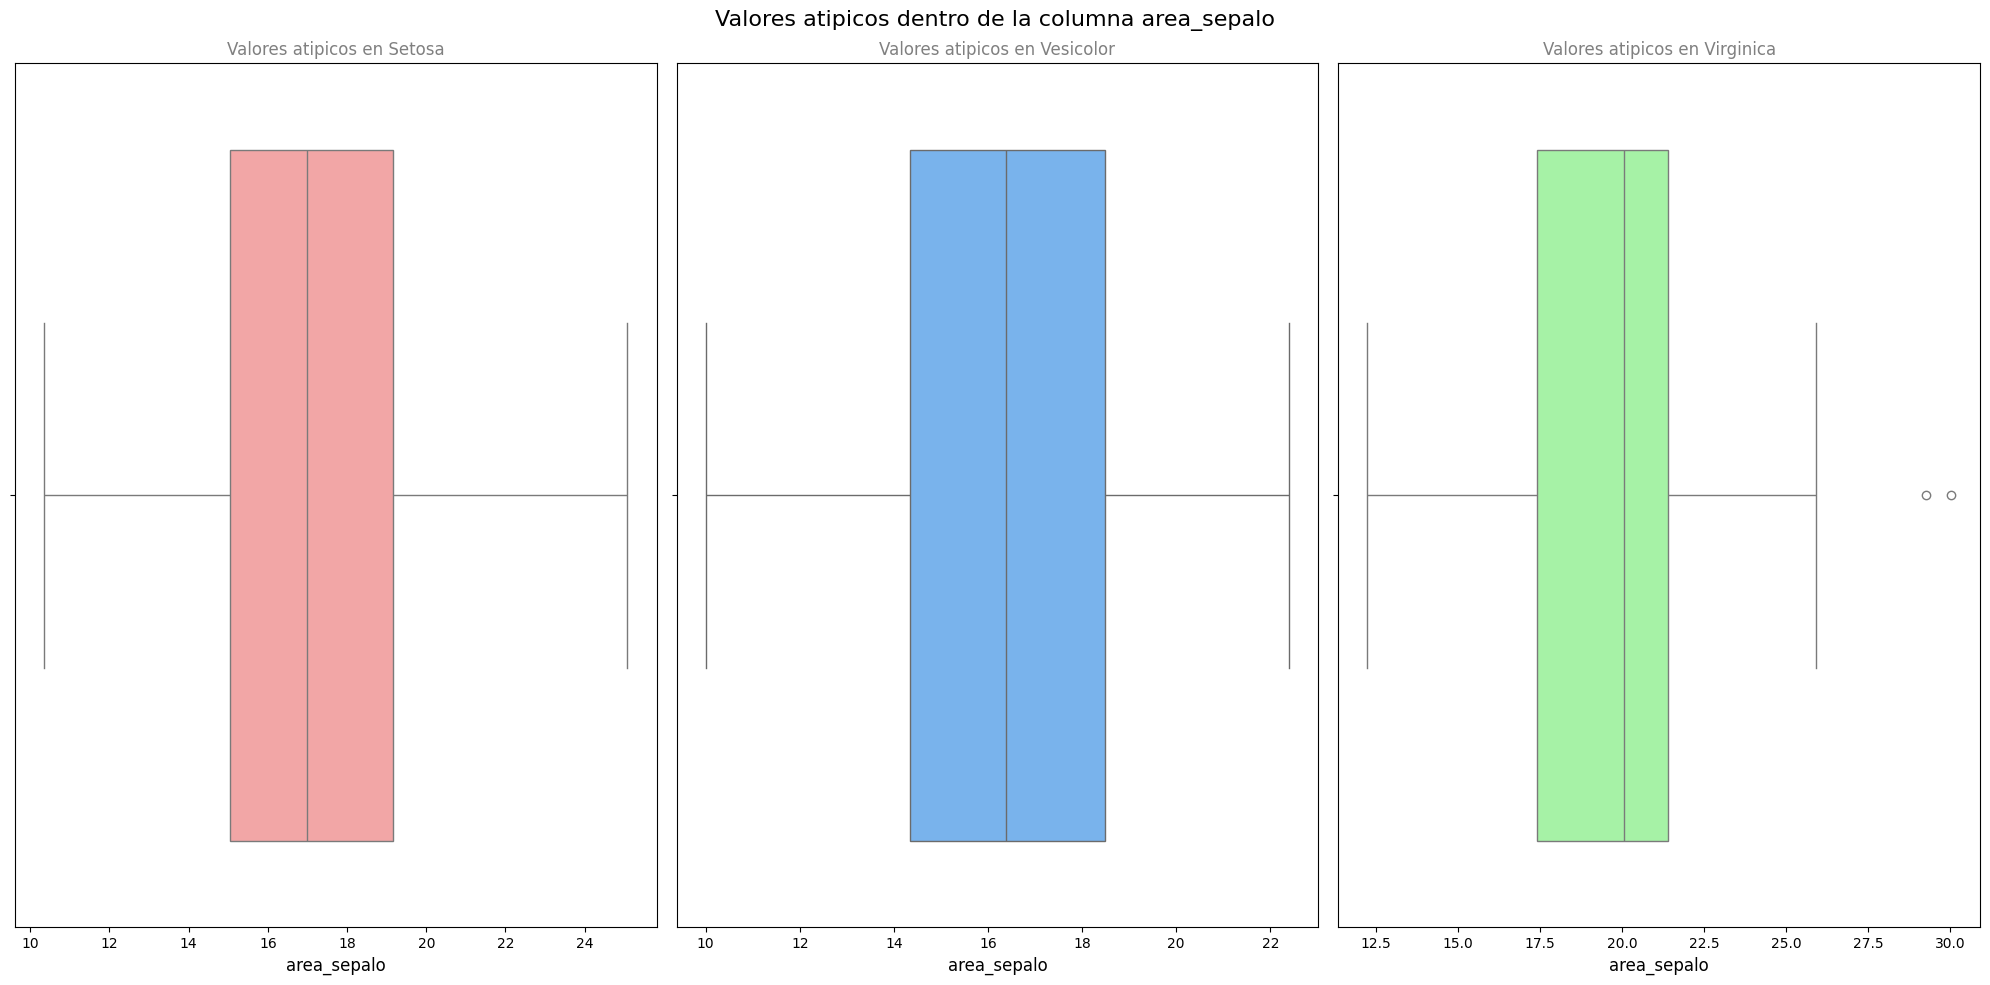

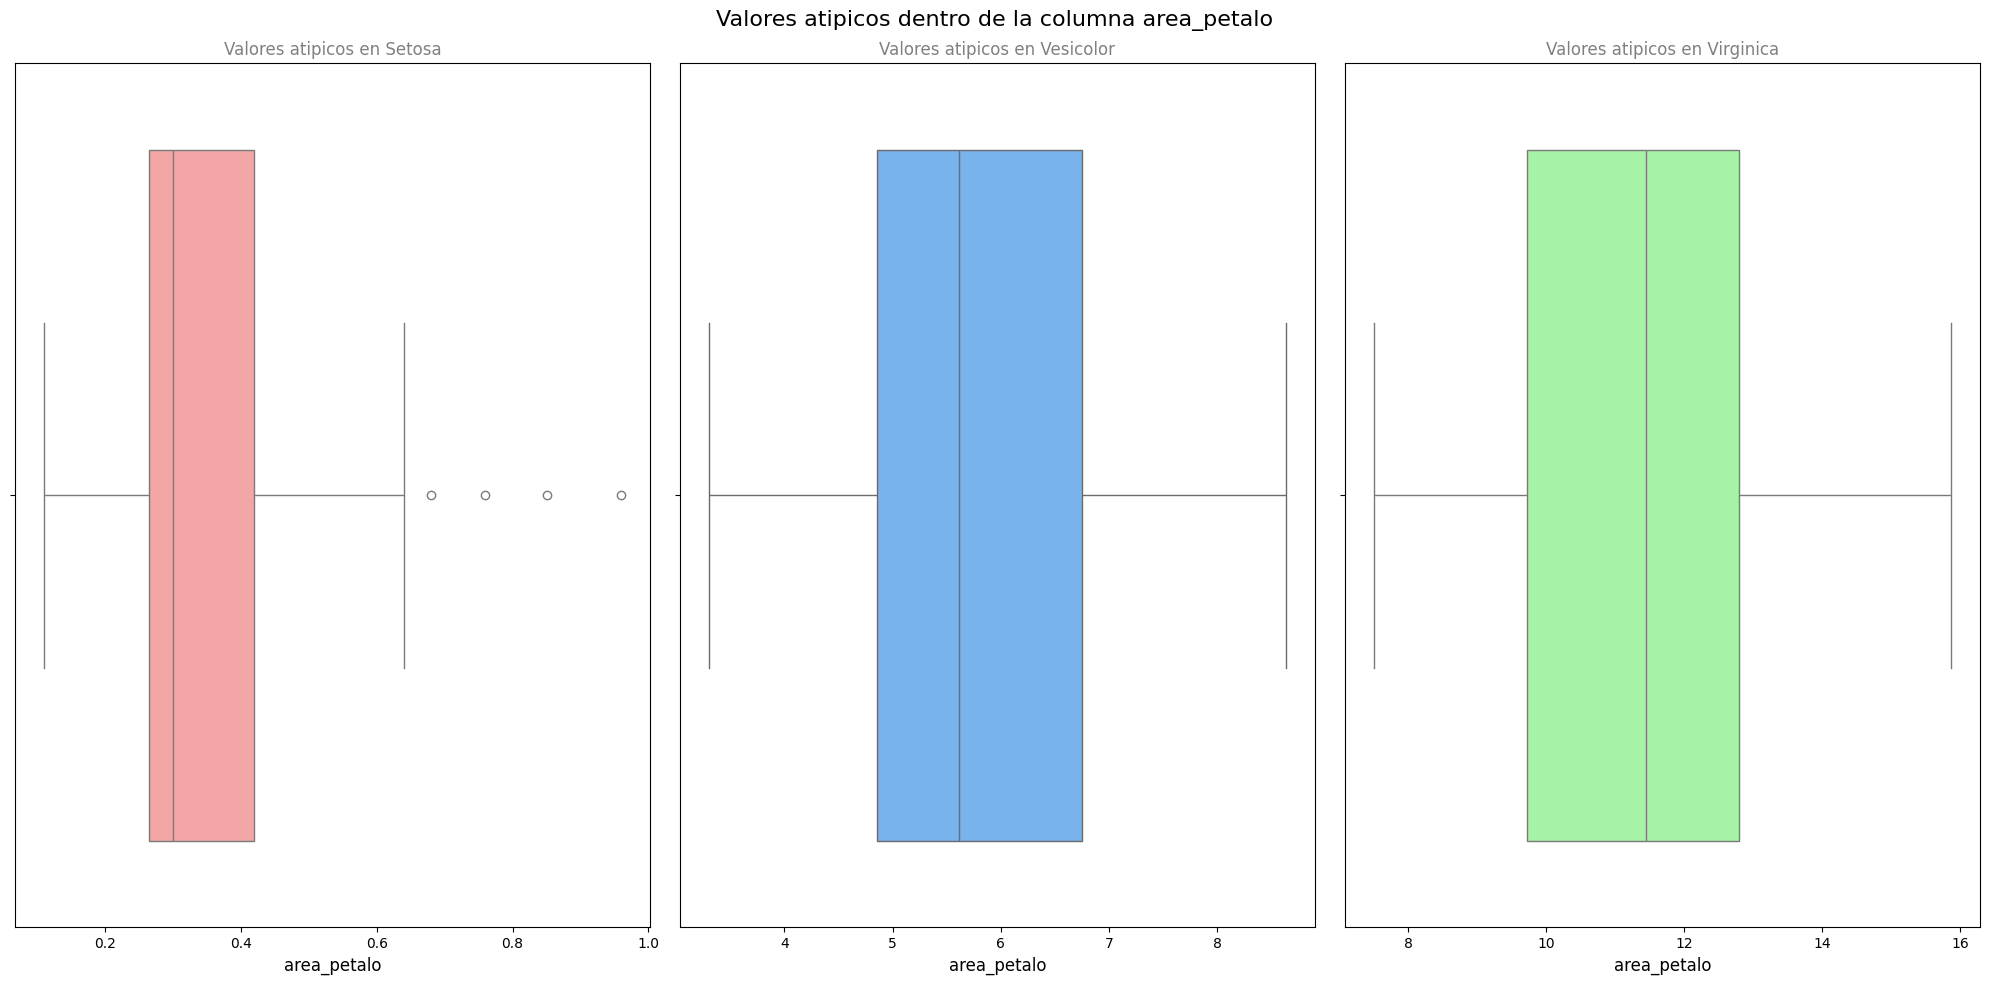

In [ ]:
cols_numericas_outliers = ['largo_petalo_cm', 'largo_sepalo_cm', 'ancho_petalo_cm', 'ancho_sepalo_cm', 'area_sepalo', 'area_petalo']

for col_name in cols_numericas_outliers:
  limites_outliers = limite_outliers(df=df_limpio, column=col_name)

  fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(20, 10))
  plt.suptitle(t=f'Valores atipicos dentro de la columna {col_name}', fontsize=16, color='black')

  # grafico de caja
  sns.boxplot(data=df_limpio_setosa, x=col_name, ax=ax[0], color=colores_especies['Iris-setosa'])
  ax[0].set_title('Valores atipicos en Setosa', fontsize=12, color='grey')

  # grafico de caja
  sns.boxplot(data=df_limpio_versicolor, x=col_name, ax=ax[1], color=colores_especies['Iris-versicolor'])
  ax[1].set_title('Valores atipicos en Vesicolor', fontsize=12, color='grey')

  # grafico de caja
  sns.boxplot(data=df_limpio_virginica, x=col_name, ax=ax[2], color=colores_especies['Iris-virginica'])
  ax[2].set_title('Valores atipicos en Virginica', fontsize=12, color='grey')

  plt.tight_layout()

  plt.show()

  print()

### Correlacion entre variables numericas:

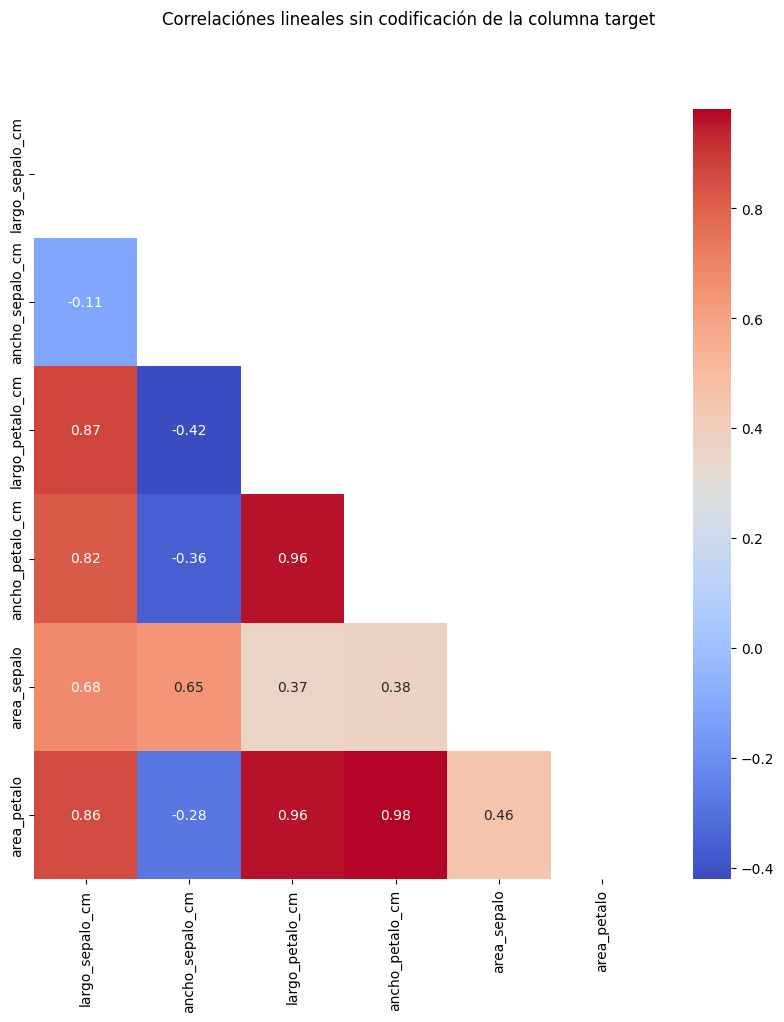

In [ ]:
# matriz de correlación
matriz_corr = df_limpio.corr(numeric_only=True)
mask_matriz_corr = np.triu(matriz_corr)

fig = plt.figure(figsize=(10, 10))
ax = sns.heatmap(data=matriz_corr, annot=True, cmap='coolwarm', mask=mask_matriz_corr)
plt.suptitle(t='Correlaciónes lineales sin codificación de la columna target')
plt.show()

### Observaciones de la etapa:

- **Correlaciones lineales:**
...

- **Correalaciones ocultas:**
...

## Analisis multivariable

Existira alguna relacion entre las vaiables?, y entre la variable categoríca con las numéricas?

In [ ]:
help(sns.lmplot)

Help on function lmplot in module seaborn.regression:

lmplot(data, *, x=None, y=None, hue=None, col=None, row=None, palette=None, col_wrap=None, height=5, aspect=1, markers='o', sharex=None, sharey=None, hue_order=None, col_order=None, row_order=None, legend=True, legend_out=None, x_estimator=None, x_bins=None, x_ci='ci', scatter=True, fit_reg=True, ci=95, n_boot=1000, units=None, seed=None, order=1, logistic=False, lowess=False, robust=False, logx=False, x_partial=None, y_partial=None, truncate=True, x_jitter=None, y_jitter=None, scatter_kws=None, line_kws=None, facet_kws=None)
    Plot data and regression model fits across a FacetGrid.
    
    This function combines :func:`regplot` and :class:`FacetGrid`. It is
    intended as a convenient interface to fit regression models across
    conditional subsets of a dataset.
    
    When thinking about how to assign variables to different facets, a general
    rule is that it makes sense to use ``hue`` for the most important
    comparis

<Figure size 1000x1000 with 0 Axes>

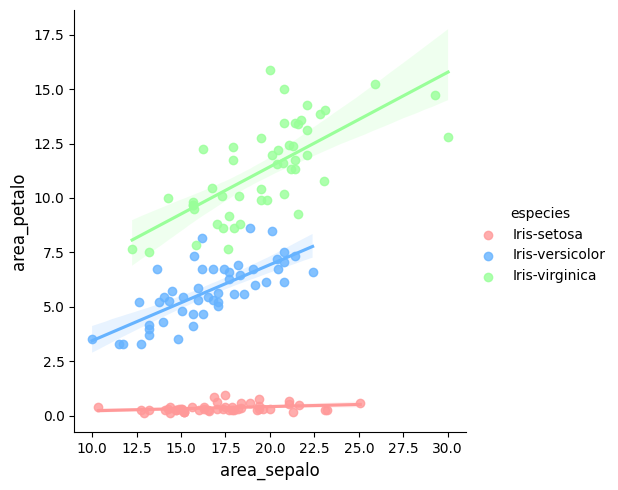

In [ ]:
# implot entre cada area respecto a la target 'species'
plt.suptitle(t='Relación entre areas y especies')
sns.lmplot(data=df_limpio, x='area_sepalo', y='area_petalo', hue='especies', palette=colores_especies)
plt.show()

<Figure size 1000x1000 with 0 Axes>

<Figure size 1500x1500 with 0 Axes>

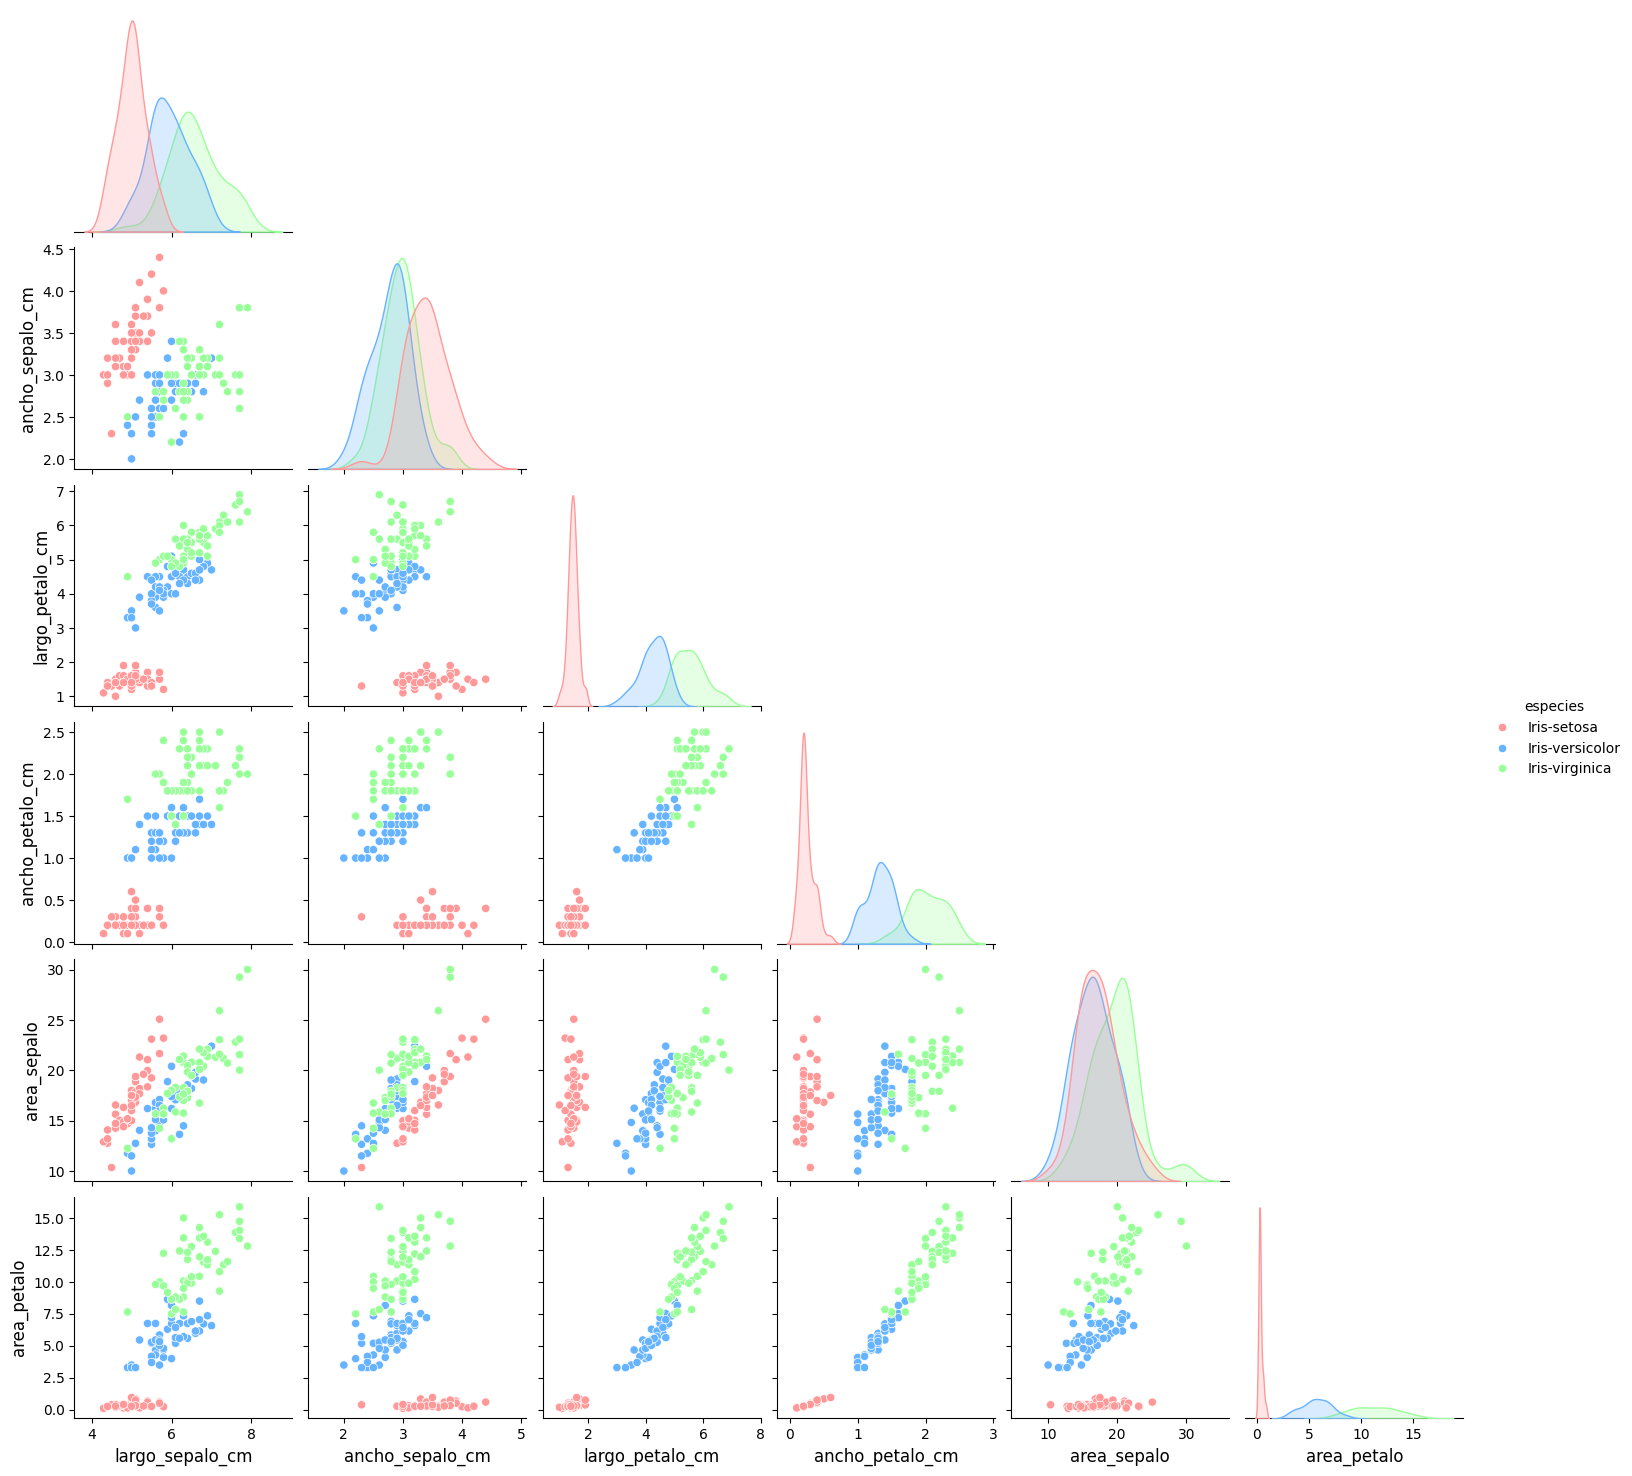

In [ ]:
# pairplot

plt.suptitle(t='Relación entre cada para de columnas y la columna target "especies"')
fig = plt.figure(figsize=(15, 15))
ax = sns.pairplot(data= df_limpio, corner=True, hue='especies', palette=colores_especies)

plt.show()

**Recomendaciones para las siguientes etapas:**

- Codificación de variables / columnas categoricas:
- Escalamiento de variables / columnas numéricas

---

# Preprocesamiento / ingenieria de caracteristicas

Imputación de nulos

In [ ]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


Codificacion de categóricas

In [ ]:
ohe_especies = OneHotEncoder(handle_unknown='warn', sparse_output=False)

ohe_especies.fit(df_limpio['especies'].to_frame())
especies_ohe = ohe_especies.transform(df_limpio['especies'].to_frame())

In [ ]:
df_especies_encoded = pd.DataFrame(data=especies_ohe, columns=ohe_especies.get_feature_names_out(), index = df_limpio.index)
df_encoded = pd.concat([df_limpio, df_especies_encoded], axis=1)
df_encoded.drop(columns=['especies'], inplace=True)

In [ ]:
df_encoded.sample(n=3)

,largo_sepalo_cm,ancho_sepalo_cm,largo_petalo_cm,ancho_petalo_cm,area_sepalo,area_petalo,especies_Iris-setosa,especies_Iris-versicolor,especies_Iris-virginica
40,5.00,3.50,1.30,0.30,17.50,0.39,1.00,0.00,0.00
147,6.50,3.00,5.20,2.00,19.50,10.40,0.00,0.00,1.00
37,4.90,3.10,1.50,0.10,15.19,0.15,1.00,0.00,0.00


Escalamiento de columnas numéricas

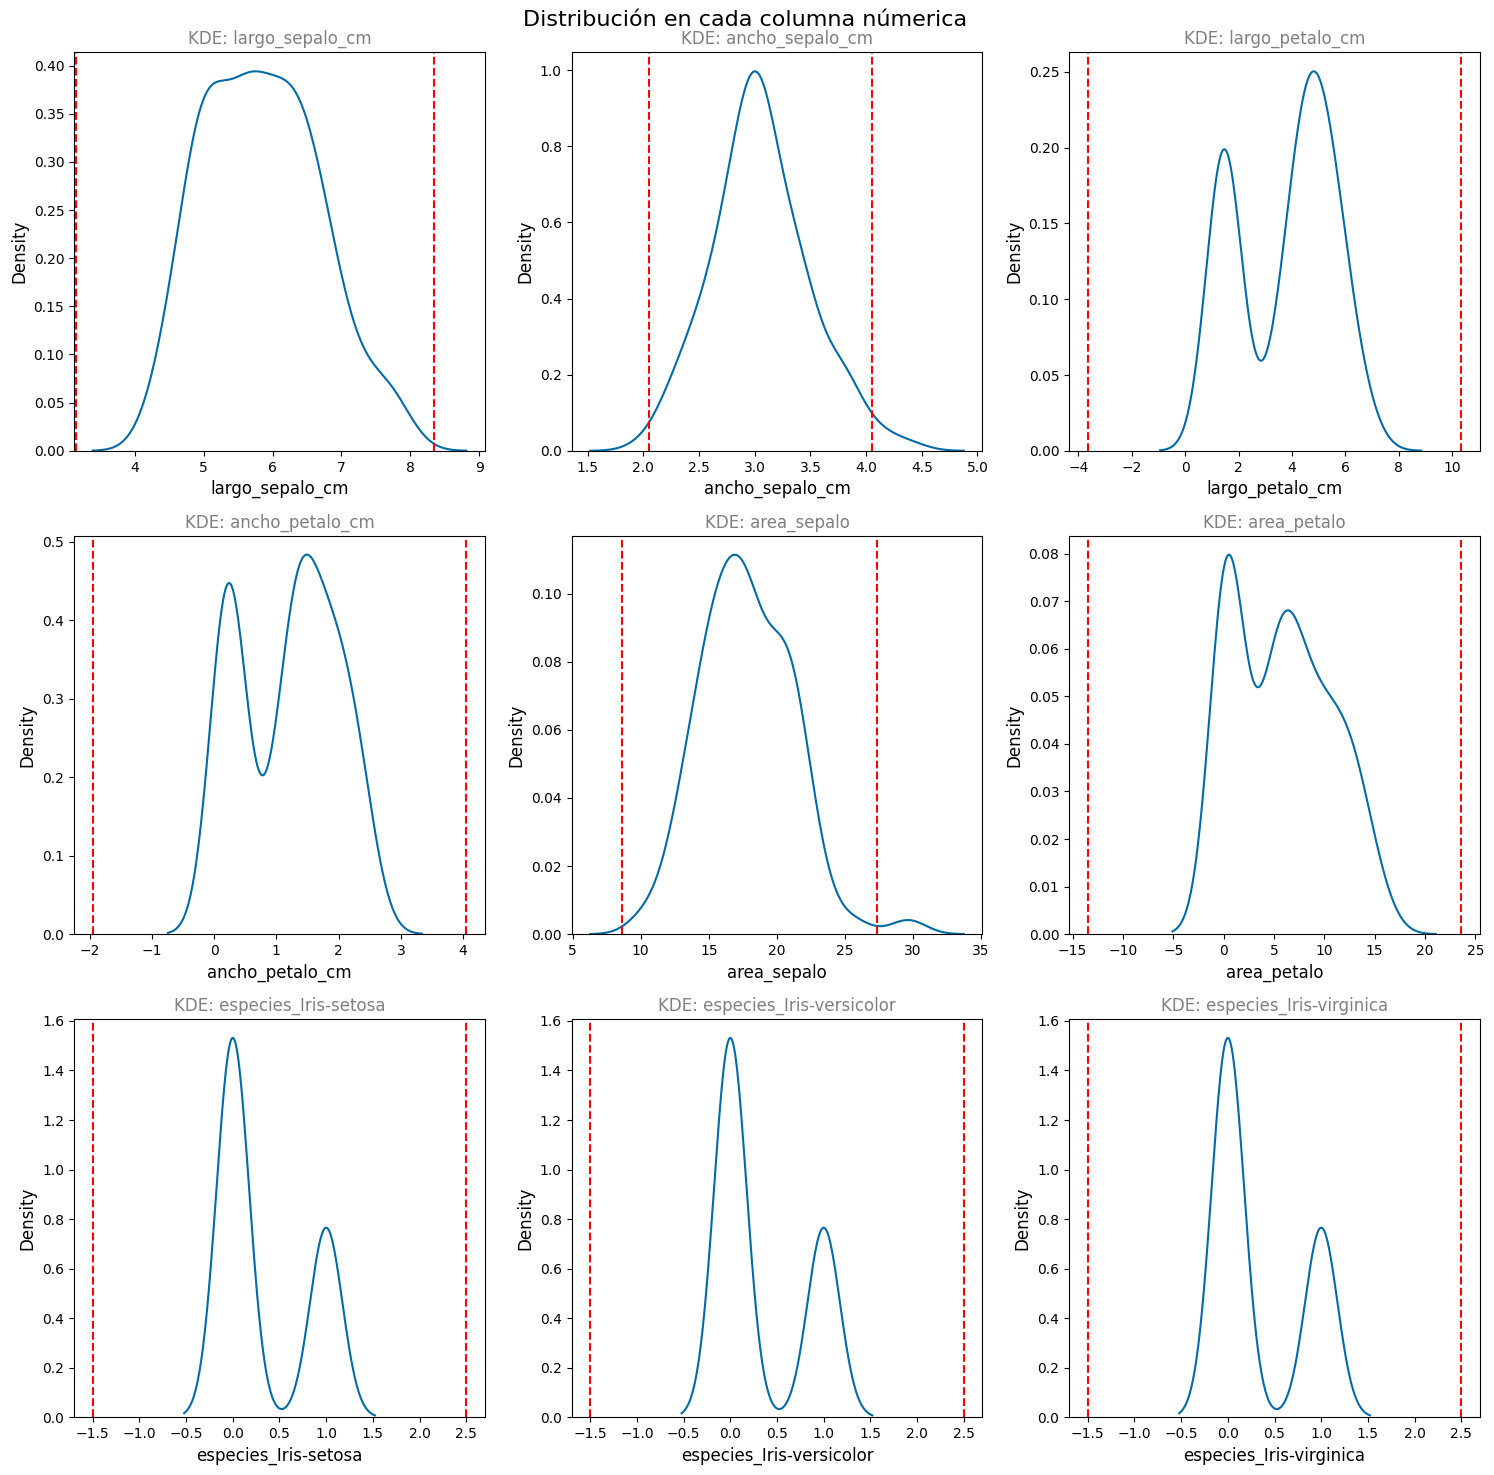

In [ ]:
n_rows = 3
n_cols = df_encoded.shape[1] // n_rows

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 15))
plt.suptitle(t='Distribución en cada columna númerica', fontsize=16, color='black')

indice_columna = 0

for row_number in range(n_rows):
  for col_number in range(n_cols):
    col_name = df_encoded.iloc[:, indice_columna].name
    limites_outliers = limite_outliers(df=df_encoded, column=col_name)
    sns.kdeplot(data=df_encoded, x=col_name, ax= ax[row_number, col_number])
    ax[row_number, col_number].axvline(x=limites_outliers['limite_inferior'], c='red', linestyle='dashed')
    ax[row_number, col_number].axvline(x=limites_outliers['limite_superior'], c='red', linestyle='dashed')
    ax[row_number, col_number].set_title(label=f'KDE: {col_name}', fontsize=12, color='grey')

    indice_columna += 1

plt.tight_layout()
plt.show()

Escalamiento de columnas numéricas

In [ ]:
df_encoeded_scaled = df_encoded.copy()

In [ ]:
# minmaxscaler
cols_bimodales = ['largo_petalo_cm', 'ancho_petalo_cm', 'area_petalo', 'especies_Iris-setosa', 'especies_Iris-versicolor', 'especies_Iris-virginica']

bimodal_m_m_scaler = MinMaxScaler()
bimodal_m_m_scaler.fit(df_encoeded_scaled[cols_bimodales])
df_encoeded_scaled[cols_bimodales] = bimodal_m_m_scaler.transform(df_encoeded_scaled[cols_bimodales])

In [ ]:
# standardscaler
cols_gauseanas = [col for col in df_encoeded_scaled.columns if col not in cols_bimodales]

gausean_m_m_scaler = MinMaxScaler()
gausean_m_m_scaler.fit(df_encoeded_scaled[cols_gauseanas])
df_encoeded_scaled[cols_gauseanas] = gausean_m_m_scaler.transform(df_encoeded_scaled[cols_gauseanas])

In [ ]:
df_encoeded_scaled.sample(n=2)

,largo_sepalo_cm,ancho_sepalo_cm,largo_petalo_cm,ancho_petalo_cm,area_sepalo,area_petalo,especies_Iris-setosa,especies_Iris-versicolor,especies_Iris-virginica
71,0.50,0.33,0.51,0.50,0.35,0.32,0.00,1.00,0.00
65,0.67,0.46,0.58,0.54,0.54,0.38,0.00,1.00,0.00


Corelaciones lineales luego de codificación y escalamiento:

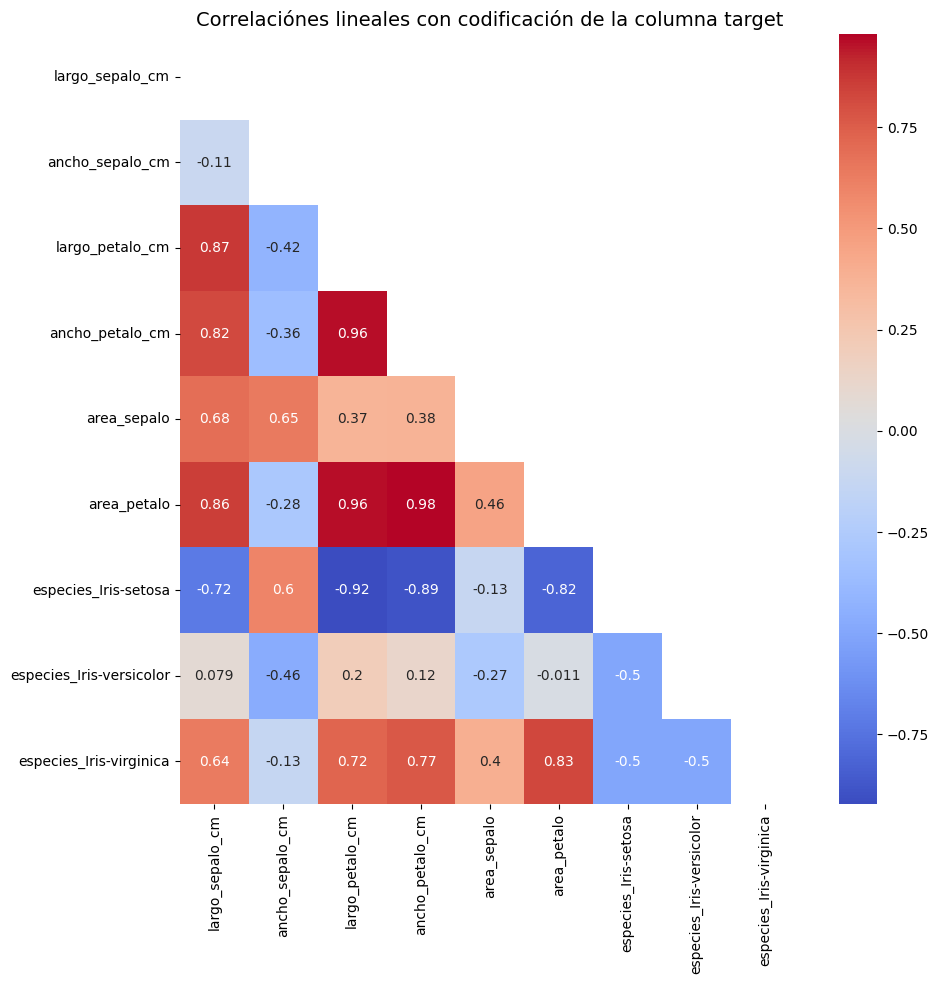

In [ ]:
encoded_corr = df_encoeded_scaled.corr()
mask_corr = np.triu(encoded_corr)

sns.heatmap(data=encoded_corr, annot=True, cmap='coolwarm', mask=mask_corr)
plt.title(label='Correlaciónes lineales con codificación de la columna target')
plt.show()

Observación de la etapa:

- Codificación de variables categróricas:
- Escalamiento de variables numéricas:

---

## Almacenamiento de utilidades

### Dataframes en datasets .csv

In [ ]:
!mkdir data

In [ ]:
df_limpio.to_csv('./data/iris_limpio.csv')

In [ ]:
df_limpio_setosa.to_csv('./data/iris_limpio_setosa_.csv')
df_limpio_versicolor.to_csv('./data/iris_limpio_versicolor.csv')
df_limpio_virginica.to_csv('./data/iris_limpio_virginica.csv')

In [ ]:
df_encoded.to_csv('./data/iris_encoded.csv')

In [ ]:
df_encoeded_scaled.to_csv('./data/iris_encoded_scaled.csv')

### Transformadores

In [ ]:
!mkdir transformadores

In [ ]:
joblib.dump(ohe_especies, './transformadores/ohe_especies.joblib')

['./transformadores/ohe_especies.joblib']

In [ ]:
joblib.dump(bimodal_m_m_scaler, './transformadores/bimodal_m_m_scaler.joblib')
joblib.dump(gausean_m_m_scaler, './transformadores/gausean_m_m_scaler.joblib')

['./transformadores/gausean_m_m_scaler.joblib']